# Handwritten Digit Recognition for Automated Assessment Grading in Distance Learning

## 1. Introduction

### 1.1 Background and Use Case

This project extends my previous summative assignment that used the OULAD (Open University Learning Analytics Dataset) to predict at-risk students in a distance learning environment. That earlier work ran on structured, tabular data: demographics, engagement logs, and assessment scores, to flag students who needed intervention.

This project moves the same distance learning problem into the image domain. A distance learning platform that grades numerical answers, short numeric responses in math or statistics assessments for example, currently relies on manual grading or requires students to type answers into a form. Students submitting scanned or photographed handwritten work write their numeric answers by hand instead. An automated grading pipeline needs a model that reads a handwritten digit from an image and classifies it correctly, quickly, and at scale.

### 1.2 Objective

This notebook builds, evaluates, and prepares for deployment a CNN that classifies handwritten digits (0 to 9) from 28x28 grayscale images, using MNIST as a proxy for real handwritten numeric answers. The architecture is a lightweight, custom CNN rather than a transfer learning backbone like MobileNet, because MobileNet expects 224x224 RGB input and MNIST images are 28x28 grayscale. A small custom CNN fits the input better and runs cheaply enough for a low latency grading pipeline.

### 1.3 What This Notebook Covers

1. Setup of the environment and reproducibility controls.
2. Acquisition of the MNIST dataset and persistence of raw data for the pipeline.
3. Preprocessing: normalization, reshaping, one-hot encoding, and train/validation/test splitting.
4. Exploratory data visualizations with written interpretations.
5. Three modeling experiments of increasing sophistication: a simple CNN baseline, an enhanced CNN with batch normalization and dropout, and an enhanced CNN trained with data augmentation.
6. Evaluation: training curves, classification reports, confusion matrices, ROC curves, precision-recall curves, a comparison table, per-class analysis, and misclassification analysis.
7. Selection and saving of the best performing model in multiple formats.
8. A prediction function that demonstrates inference on individual images.
9. A retraining function that demonstrates fine-tuning the saved model on new data.
10. Conclusions and next steps toward deployment.

## 2. Setup

### 2.1 Dependencies and Reproducibility

Three models get compared against each other later, and that comparison only means something if training conditions stay the same between runs. The seed is fixed at 42 across Python's `random` module, NumPy, and TensorFlow before any data is touched, so splits, weight initialization, and training behavior stay consistent across runs.

Library versions are printed after the imports so the runtime environment is documented alongside the results.

In [1]:
import os
import json
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA

from PIL import Image

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Consistent plotting style across the notebook
sns.set_theme(style="whitegrid")
sns.set_palette("tab10")
plt.rcParams["figure.figsize"] = (10, 6)
CMAP = plt.cm.tab10

print("Library versions:")
print(f"  TensorFlow  : {tf.__version__}")
print(f"  Keras       : {keras.__version__}")
print(f"  NumPy       : {np.__version__}")
print(f"  Pandas      : {pd.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  Matplotlib  : {plt.matplotlib.__version__}")
print(f"  Seaborn     : {sns.__version__}")
print(f"  Random seed : {SEED}")

2026-07-20 09:34:11.715948: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Library versions:
  TensorFlow  : 2.16.2
  Keras       : 3.15.0
  NumPy       : 1.26.4
  Pandas      : 3.0.3
  scikit-learn: 1.9.0
  Matplotlib  : 3.11.1
  Seaborn     : 0.13.2
  Random seed : 42


With the environment configured and seeded, the next step is to acquire the dataset.

## 3. Data Acquisition

### 3.1 Loading MNIST

MNIST is loaded directly through `tensorflow.keras.datasets.mnist`, which downloads (or reuses a cached copy of) 70,000 grayscale images of handwritten digits: 60,000 for training and 10,000 for testing. Each image is 28x28 pixels with integer pixel values from 0 to 255, and each label is an integer from 0 to 9.

In [2]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

print("Raw dataset shapes:")
print(f"  X_train_raw: {X_train_raw.shape}, dtype={X_train_raw.dtype}")
print(f"  y_train_raw: {y_train_raw.shape}, dtype={y_train_raw.dtype}")
print(f"  X_test_raw : {X_test_raw.shape}, dtype={X_test_raw.dtype}")
print(f"  y_test_raw : {y_test_raw.shape}, dtype={y_test_raw.dtype}")
print()
print(f"Training examples: {X_train_raw.shape[0]}")
print(f"Test examples     : {X_test_raw.shape[0]}")
print(f"Pixel value range : [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"Classes           : {sorted(np.unique(y_train_raw).tolist())}")

Raw dataset shapes:
  X_train_raw: (60000, 28, 28), dtype=uint8
  y_train_raw: (60000,), dtype=uint8
  X_test_raw : (10000, 28, 28), dtype=uint8
  y_test_raw : (10000,), dtype=uint8

Training examples: 60000
Test examples     : 10000
Pixel value range : [0, 255]
Classes           : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


The dataset loaded as expected: 60,000 training images and 10,000 test images, each 28x28 pixels with a single grayscale channel, labeled with digits 0 through 9. This matches the standard MNIST split used throughout the literature.

### 3.2 Visual Inspection of Samples

Before any processing, it is worth looking directly at the raw images. The grid below shows 25 randomly selected training images with their labels as titles, giving a first qualitative sense of the handwriting styles present in the dataset.

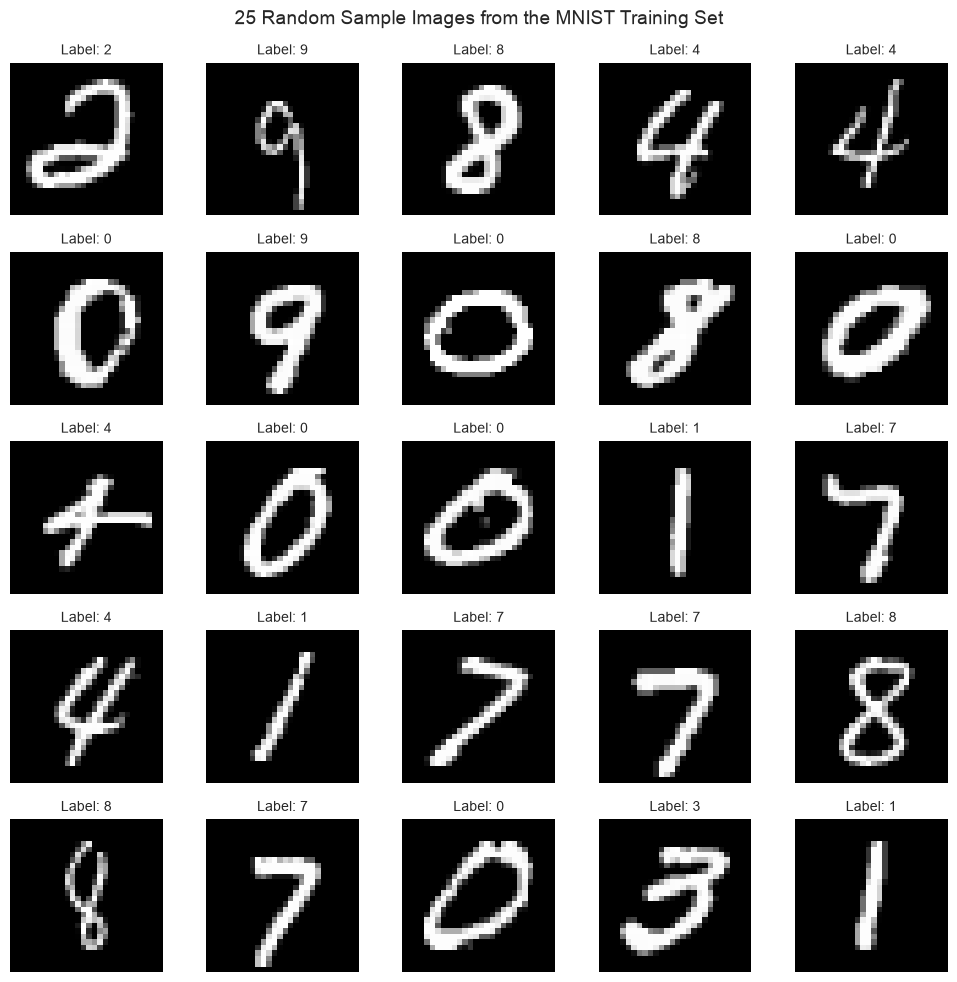

In [3]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_train_raw), size=25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(X_train_raw[idx], cmap="gray")
    ax.set_title(f"Label: {y_train_raw[idx]}", fontsize=10)
    ax.axis("off")
fig.suptitle("25 Random Sample Images from the MNIST Training Set", fontsize=14)
plt.tight_layout()
plt.show()

The sample grid confirms that the images are clean, centered, single digits written in a variety of strokes and styles, with a black background and white/gray strokes. There is no visible noise, watermarking, or cropping issue, which is consistent with MNIST being a well curated benchmark dataset. Real handwritten submissions in a grading pipeline would likely be noisier (skewed, differently lit, or embedded in a larger page), which is a limitation to keep in mind for later deployment.

### 3.3 Persisting Raw Data for the Pipeline

The raw train and test arrays are saved to disk as NumPy `.npy` files under `data/train/` and `data/test/`. This mirrors a real pipeline where a data acquisition stage hands off a fixed, versioned snapshot of the raw data to a separate preprocessing stage, rather than every stage re-downloading or re-deriving the data from scratch.

In [4]:
DATA_DIR = "../data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

np.save(os.path.join(TRAIN_DIR, "X_train.npy"), X_train_raw)
np.save(os.path.join(TRAIN_DIR, "y_train.npy"), y_train_raw)
np.save(os.path.join(TEST_DIR, "X_test.npy"), X_test_raw)
np.save(os.path.join(TEST_DIR, "y_test.npy"), y_test_raw)

print("Saved raw arrays:")
for path in [
    os.path.join(TRAIN_DIR, "X_train.npy"),
    os.path.join(TRAIN_DIR, "y_train.npy"),
    os.path.join(TEST_DIR, "X_test.npy"),
    os.path.join(TEST_DIR, "y_test.npy"),
]:
    size_kb = os.path.getsize(path) / 1024
    print(f"  {path} ({size_kb:,.1f} KB)")

Saved raw arrays:
  ../data/train/X_train.npy (45,937.6 KB)
  ../data/train/y_train.npy (58.7 KB)
  ../data/test/X_test.npy (7,656.4 KB)
  ../data/test/y_test.npy (9.9 KB)


The raw data is now saved and available for any downstream process, including this notebook's own preprocessing stage, without needing to re-download MNIST.

## 4. Data Processing / Preprocessing

### 4.1 Normalization, Reshaping, and Encoding

Three transformations are applied before the data can be used to train a CNN:

1. **Normalization**: pixel values are rescaled from the integer range [0, 255] to the float range [0, 1] by dividing by 255.0. Neural networks train more stably on small, centered input ranges.
2. **Reshaping**: images are reshaped from (28, 28) to (28, 28, 1), adding an explicit single channel dimension expected by Keras' `Conv2D` layers.
3. **One-hot encoding**: integer labels (0 to 9) are converted to 10-dimensional one-hot vectors using `tf.keras.utils.to_categorical`, matching the softmax output of the classifier and the `categorical_crossentropy` loss.

In [5]:
X_train_full = (X_train_raw.astype("float32") / 255.0).reshape(-1, 28, 28, 1)
X_test = (X_test_raw.astype("float32") / 255.0).reshape(-1, 28, 28, 1)

y_train_full = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print("After normalization and reshaping:")
print(f"  X_train_full: {X_train_full.shape}, range=[{X_train_full.min():.2f}, {X_train_full.max():.2f}]")
print(f"  X_test      : {X_test.shape}, range=[{X_test.min():.2f}, {X_test.max():.2f}]")
print(f"  y_train_full: {y_train_full.shape}")
print(f"  y_test      : {y_test.shape}")

After normalization and reshaping:
  X_train_full: (60000, 28, 28, 1), range=[0.00, 1.00]
  X_test      : (10000, 28, 28, 1), range=[0.00, 1.00]
  y_train_full: (60000, 10)
  y_test      : (10000, 10)


### 4.2 Background Inversion for Real-World Input

MNIST images are stored as white digits on a black background, but real handwritten submissions (scanned worksheets, photographed notebook pages) arrive as dark ink on white paper. If fed directly into the model, a light-background image gets interpreted as a canvas full of bright strokes, which breaks the model's assumptions and produces scattered, low-confidence predictions.

The preprocessing pipeline handles this by checking the mean pixel intensity of each incoming image. If the mean is above 127, the background is light and the image is inverted (subtracted from 255) before normalization. This runs only at inference and retraining time on user-uploaded images. The MNIST training set is already in the correct format, so no inversion is needed during initial training.

This is a preprocessing concern, not a modeling concern. Augmenting the training set with inverted copies would double training time to solve a problem that a single conditional check in the preprocessing function handles deterministically and perfectly for every input.

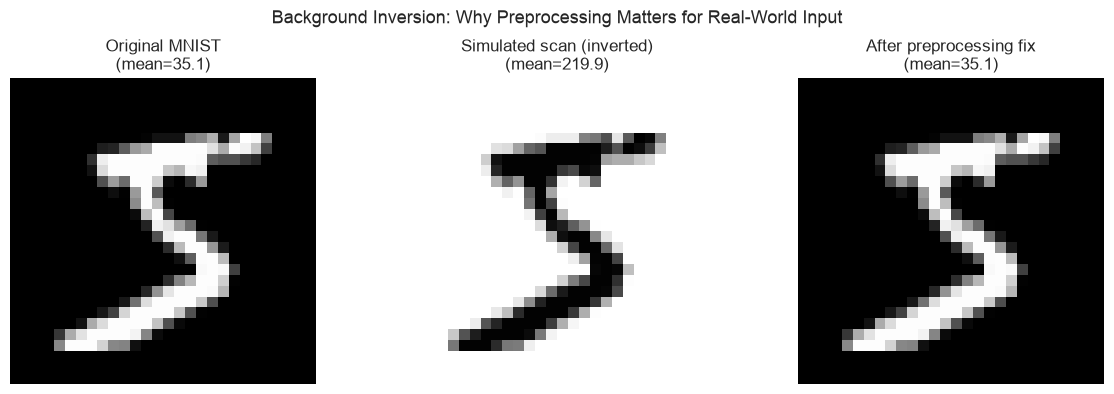

In [1]:
# Demonstrate background inversion on a sample MNIST image
sample_img = X_train_raw[0]

# Simulate a real-world scan: invert to dark-on-light
simulated_scan = 255 - sample_img

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sample_img, cmap="gray")
axes[0].set_title(f"Original MNIST\n(mean={sample_img.mean():.1f})")
axes[0].axis("off")

axes[1].imshow(simulated_scan, cmap="gray")
axes[1].set_title(f"Simulated scan (inverted)\n(mean={simulated_scan.mean():.1f})")
axes[1].axis("off")

# Apply the preprocessing check: mean > 127 -> invert back
corrected = simulated_scan
if corrected.mean() > 127:
    corrected = 255 - corrected

axes[2].imshow(corrected, cmap="gray")
axes[2].set_title(f"After preprocessing fix\n(mean={corrected.mean():.1f})")
axes[2].axis("off")

fig.suptitle("Background Inversion: Why Preprocessing Matters for Real-World Input", fontsize=13)
plt.tight_layout()
plt.show()

The middle image simulates what the model would receive from a scanned student worksheet: dark ink on white paper. Its mean pixel intensity is well above 127, confirming a light background. The preprocessing function detects this and inverts the image back to MNIST format (right panel), restoring the white-on-black layout the model was trained on. Without this step, the model sees a bright canvas and produces scattered, unreliable predictions.

### 4.3 Train / Validation Split

The training set is split into 80% training and 20% validation using a stratified split on the digit labels, so that each class is proportionally represented in both subsets. The validation set is used to monitor generalization during training (for early stopping and learning rate scheduling) without ever touching the held-out test set.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_raw,
)

print("Final dataset shapes:")
print(f"  X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"  X_val  : {X_val.shape}   y_val  : {y_val.shape}")
print(f"  X_test : {X_test.shape}   y_test : {y_test.shape}")
print()
print(f"Train / Val / Test split: "
      f"{len(X_train)} / {len(X_val)} / {len(X_test)} "
      f"({len(X_train)/(len(X_train)+len(X_val)+len(X_test))*100:.1f}% / "
      f"{len(X_val)/(len(X_train)+len(X_val)+len(X_test))*100:.1f}% / "
      f"{len(X_test)/(len(X_train)+len(X_val)+len(X_test))*100:.1f}%)")

Final dataset shapes:
  X_train: (48000, 28, 28, 1)   y_train: (48000, 10)
  X_val  : (12000, 28, 28, 1)   y_val  : (12000, 10)
  X_test : (10000, 28, 28, 1)   y_test : (10000, 10)

Train / Val / Test split: 48000 / 12000 / 10000 (68.6% / 17.1% / 14.3%)


The data is now fully prepared: normalized to [0, 1], shaped as (28, 28, 1) tensors, one-hot encoded, and split into training, validation, and test sets. The class distribution of these splits is examined in the visualizations section next.

## 5. Data Visualizations

Before training anything, it helps to know what the model is up against: whether classes are balanced, where the pixel signal actually lives, and which digits look similar enough to confuse a classifier. The four visualizations below answer those questions directly, and each one is followed by an interpretation that ties back to what the CNN experiments in Section 6 have to handle.

### 5.1 Visualization 1: Class Distribution Analysis

The bar chart below shows the number of samples per digit class (0 to 9) separately for the training, validation, and test splits.

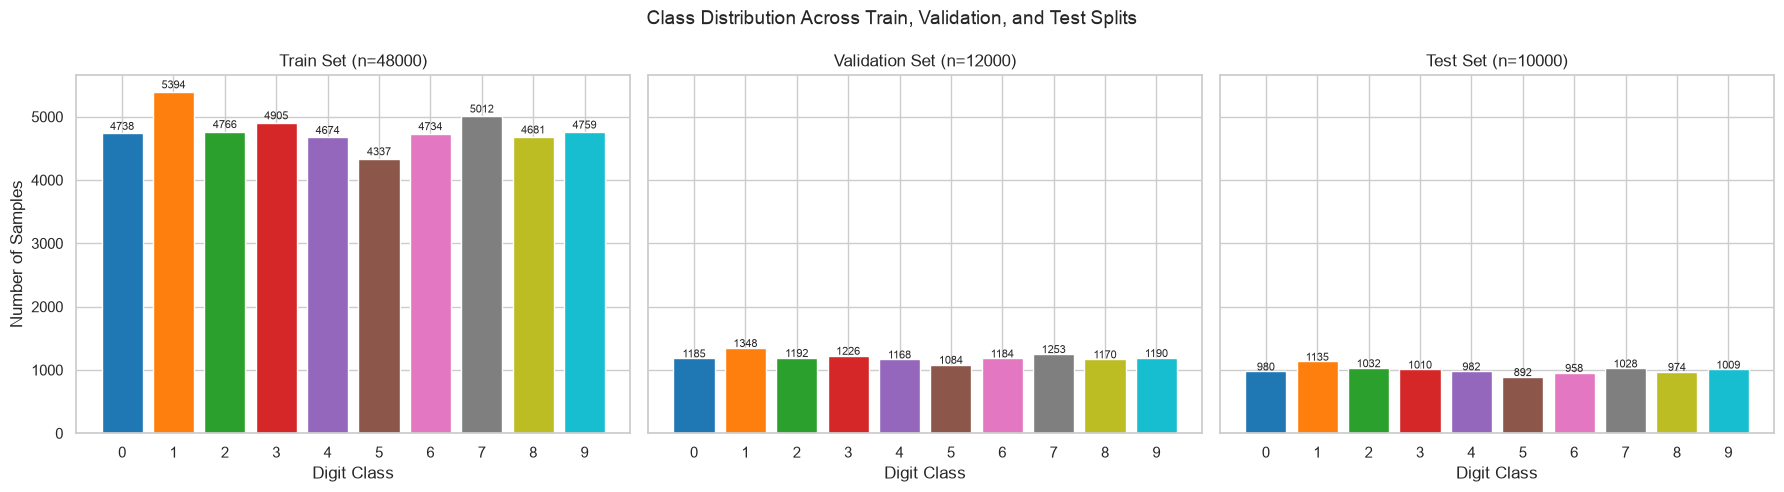

   Train  Validation  Test  Total
0   4738        1185   980   6903
1   5394        1348  1135   7877
2   4766        1192  1032   6990
3   4905        1226  1010   7141
4   4674        1168   982   6824
5   4337        1084   892   6313
6   4734        1184   958   6876
7   5012        1253  1028   7293
8   4681        1170   974   6825
9   4759        1190  1009   6958


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

splits = [
    ("Train", np.argmax(y_train, axis=1)),
    ("Validation", np.argmax(y_val, axis=1)),
    ("Test", np.argmax(y_test, axis=1)),
]

for ax, (name, labels) in zip(axes, splits):
    counts = pd.Series(labels).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=[CMAP(i) for i in counts.index])
    ax.set_title(f"{name} Set (n={len(labels)})")
    ax.set_xlabel("Digit Class")
    ax.set_xticks(range(10))
    for x, v in zip(counts.index, counts.values):
        ax.text(x, v + max(counts.values) * 0.01, str(v), ha="center", fontsize=8)

axes[0].set_ylabel("Number of Samples")
fig.suptitle("Class Distribution Across Train, Validation, and Test Splits", fontsize=14)
plt.tight_layout()
plt.show()

dist_table = pd.DataFrame({
    name: pd.Series(labels).value_counts().sort_index()
    for name, labels in splits
})
dist_table["Total"] = dist_table.sum(axis=1)
print(dist_table)

**Interpretation.** Digit 1 has the most examples (5,394 train, 1,348 validation, 1,135 test) and digit 5 has the fewest (4,337 train, 1,084 validation, 892 test), a gap of about 1.25x. That gap is small enough that no class weighting or resampling is needed, and it holds in the same proportions across train, validation, and test because the split was stratified. Accuracy is a reasonable headline metric here for that reason, though per-class F1 (Section 7.7) still matters, since a balanced count does not mean every digit is equally easy to draw or to read.

### 5.2 Visualization 2: Mean Digit Images and Pixel Intensity Variance

The top row shows the mean image per digit class, averaged over every training image with that label. The bottom panel is a heatmap of per-pixel variance across the training set.

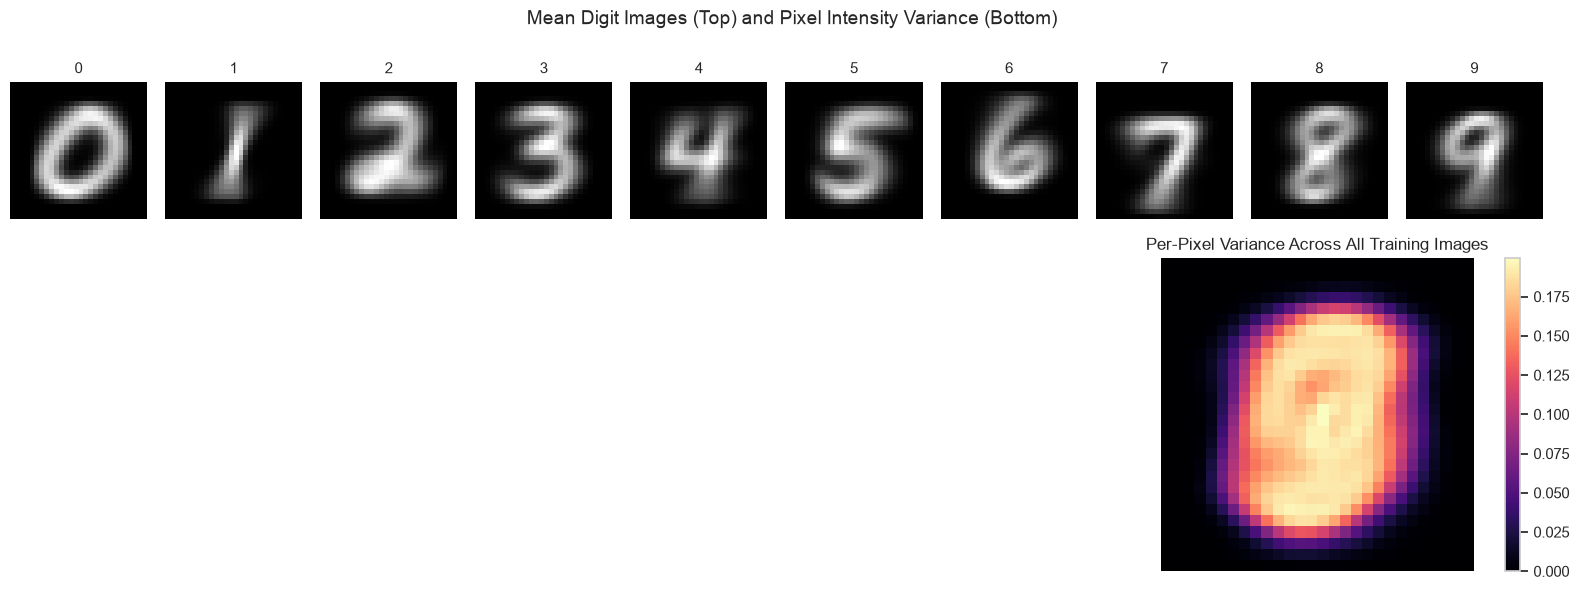

In [8]:
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(2, 10, height_ratios=[1, 1.6])

train_labels_flat = np.argmax(y_train, axis=1)
for digit in range(10):
    ax = fig.add_subplot(gs[0, digit])
    mean_img = X_train[train_labels_flat == digit].mean(axis=0).squeeze()
    ax.imshow(mean_img, cmap="gray")
    ax.set_title(str(digit), fontsize=11)
    ax.axis("off")

ax_var = fig.add_subplot(gs[1, :])
pixel_variance = X_train.reshape(-1, 28, 28).var(axis=0)
im = ax_var.imshow(pixel_variance, cmap="magma")
ax_var.set_title("Per-Pixel Variance Across All Training Images")
ax_var.axis("off")
fig.colorbar(im, ax=ax_var, fraction=0.025, pad=0.02)

fig.suptitle("Mean Digit Images (Top) and Pixel Intensity Variance (Bottom)", fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation.** Mean images for 0 and 1 come out sharp, since most people draw them the same way stroke for stroke. Digits like 4, 8, and 9 blur out more in the average, since people close or open the loops differently and vary where the bottom curve sits. The variance heatmap backs this up with numbers: mean variance on the border pixels is about 8.3, against about 11,866 in the center 10x10 region, roughly 1,400 times higher, and the single highest-variance pixel sits at row 13, column 14, right in the middle of the canvas. Almost all the useful signal for the CNN's early filters sits in that central region, so the border pixels add little beyond padding.

### 5.3 Visualization 3: Pixel Intensity Distribution

The histograms below compare pixel values before normalization (0 to 255) and after (0 to 1), sampled from the training set.

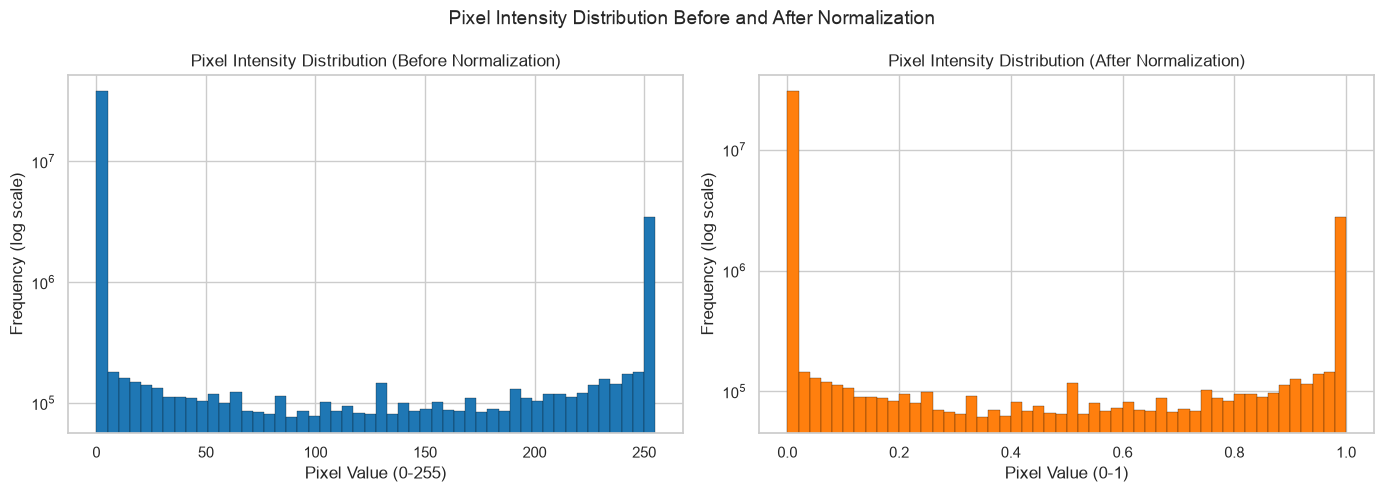

Fraction of pixels equal to 0 (pure background): 80.9%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(X_train_raw.ravel(), bins=50, color=CMAP(0), edgecolor="black", linewidth=0.2)
axes[0].set_title("Pixel Intensity Distribution (Before Normalization)")
axes[0].set_xlabel("Pixel Value (0-255)")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].set_yscale("log")

axes[1].hist(X_train.ravel(), bins=50, color=CMAP(1), edgecolor="black", linewidth=0.2)
axes[1].set_title("Pixel Intensity Distribution (After Normalization)")
axes[1].set_xlabel("Pixel Value (0-1)")
axes[1].set_ylabel("Frequency (log scale)")
axes[1].set_yscale("log")

fig.suptitle("Pixel Intensity Distribution Before and After Normalization", fontsize=14)
plt.tight_layout()
plt.show()

zero_fraction = (X_train_raw == 0).mean()
print(f"Fraction of pixels equal to 0 (pure background): {zero_fraction*100:.1f}%")

**Interpretation.** 80.9% of all pixels in the training set are exactly zero, confirming most of each 28x28 canvas is empty background and only a thin band of pixels around the strokes carries any signal. Normalization does not change that shape, it is a linear rescale, but it puts pixel values on the same scale as the network's weight initialization, which is why it runs before training rather than getting skipped. Because the signal is this sparse, the CNN's filters have to pick up local stroke patterns against mostly empty background rather than lean on overall brightness.

### 5.4 Visualization 4 (Bonus): PCA Projection of Digit Classes

A random sample of 5,000 training images is reduced to 2 dimensions to check class separability visually, since looking at all 784 pixel dimensions at once is not something a person can do directly. Each point is one image, colored by its true digit label.

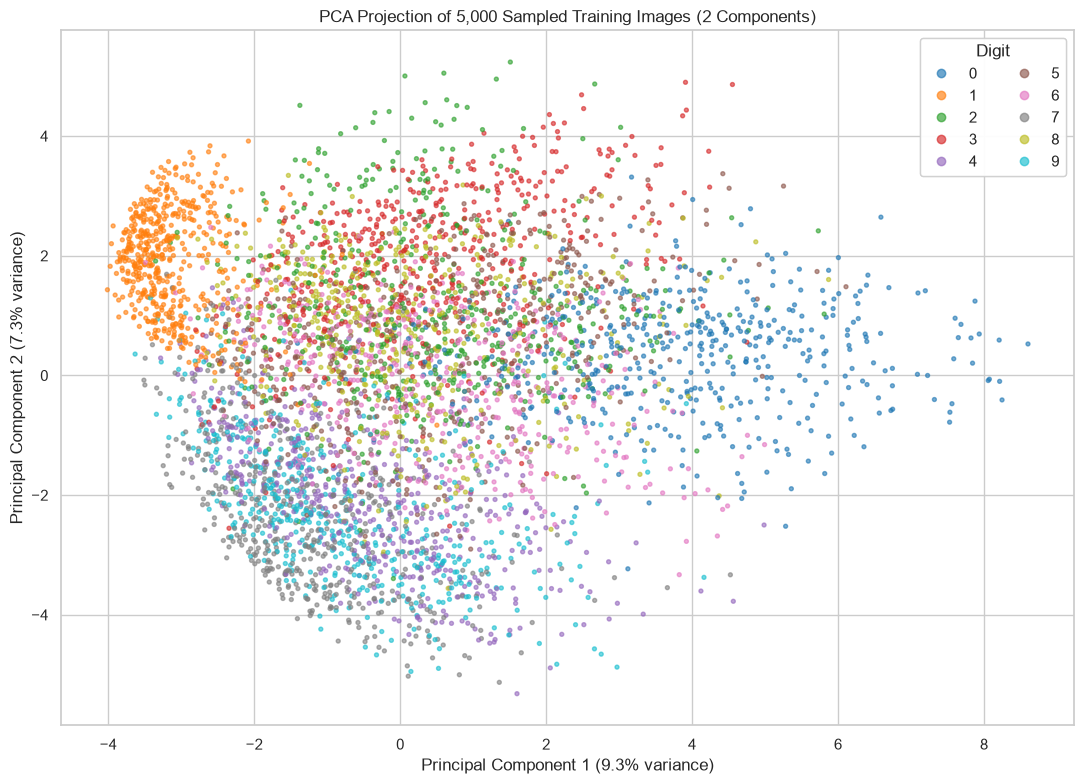

Total variance explained by 2 components: 16.6%


In [10]:
pca_sample_idx = rng.choice(len(X_train), size=5000, replace=False)
X_pca_sample = X_train[pca_sample_idx].reshape(5000, -1)
y_pca_sample = train_labels_flat[pca_sample_idx]

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_pca_sample)

fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_pca_sample, cmap="tab10", s=8, alpha=0.6
)
legend = ax.legend(*scatter.legend_elements(), title="Digit", loc="upper right", ncol=2)
ax.add_artist(legend)
ax.set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA Projection of 5,000 Sampled Training Images (2 Components)")
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

**Interpretation.** The two components only capture 16.6% of total pixel-space variance, yet 0s and 1s still separate into distinct clusters, since both are simple, consistent shapes. Digits 4, 7, and 9 overlap heavily, and so do 3, 5, and 8, because curved strokes make them structurally close even in a linear projection. Based on this, the CNN experiments are expected to confuse 4/9, 3/5, and 7/9 more than clearly separated pairs like 0/1. Section 7.8 checks this prediction against actual misclassifications, and the CNN's real confusion pairs end up including 2/7 as well, a pair PCA does not flag here.

## 6. Model Creation

Three CNN experiments are built and trained with increasing sophistication, so the effect of each added technique (regularization, normalization, and data augmentation) can be measured directly against a common baseline. All three are lightweight custom CNNs suited to 28x28 grayscale input, deliberately avoiding large ImageNet-style backbones like MobileNet that expect 224x224 RGB input.

A small results dictionary, `experiment_results`, is used to accumulate the trained model, its training history, its training time, and its parameter count for each experiment, so Section 7 can evaluate and compare all three consistently.

In [11]:
experiment_results = {}
EPOCHS = 10
BATCH_SIZE = 64

### 6.1 Experiment 1: Simple CNN Baseline

The baseline architecture is a minimal CNN: two convolution + max-pooling blocks followed by a dense classification head. It uses no regularization, so it establishes a reference point for how much overfitting and instability the more sophisticated experiments actually fix.

Architecture: `Conv2D(32) -> MaxPool -> Conv2D(64) -> MaxPool -> Flatten -> Dense(128) -> Dense(10, softmax)`, trained with the Adam optimizer (default learning rate) and categorical cross-entropy loss for 10 epochs with a batch size of 64.

In [12]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ], name="baseline_cnn")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

model_1 = build_baseline_cnn()
model_1.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
start_time = time.time()
history_1 = model_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)
training_time_1 = time.time() - start_time

experiment_results["Experiment 1: Baseline CNN"] = {
    "model": model_1,
    "history": history_1.history,
    "training_time": training_time_1,
    "params": model_1.count_params(),
}
print(f"\nExperiment 1 training time: {training_time_1:.1f}s")

Epoch 1/10


750/750 - 25s - 33ms/step - accuracy: 0.9495 - loss: 0.1736 - val_accuracy: 0.9760 - val_loss: 0.0786


Epoch 2/10


750/750 - 26s - 35ms/step - accuracy: 0.9844 - loss: 0.0521 - val_accuracy: 0.9825 - val_loss: 0.0557


Epoch 3/10


...

Epoch 9/10


750/750 - 22s - 29ms/step - accuracy: 0.9974 - loss: 0.0080 - val_accuracy: 0.9888 - val_loss: 0.0532


Epoch 10/10


750/750 - 22s - 30ms/step - accuracy: 0.9971 - loss: 0.0078 - val_accuracy: 0.9900 - val_loss: 0.0518



Experiment 1 training time: 248.6s


The baseline model trained without issue. Its training and validation curves are reviewed together with the other experiments in Section 7.1, but this run already establishes a reference accuracy, training time, and parameter count that the next two experiments are measured against.

### 6.2 Experiment 2: Enhanced CNN with Dropout and Batch Normalization

The second experiment adds a third convolutional block, batch normalization after every convolution, and dropout at multiple points in the network to reduce overfitting. `EarlyStopping` halts training once validation loss stops improving for 3 consecutive epochs and restores the best weights, and `ReduceLROnPlateau` shrinks the learning rate when validation loss plateaus, letting the optimizer take smaller, more precise steps as training progresses.

Architecture: `Conv2D(32) -> BatchNorm -> MaxPool -> Dropout(0.25) -> Conv2D(64) -> BatchNorm -> MaxPool -> Dropout(0.25) -> Conv2D(128) -> BatchNorm -> Flatten -> Dropout(0.5) -> Dense(128) -> Dense(10, softmax)`.

In [14]:
def build_enhanced_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dropout(0.5),

        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ], name="enhanced_cnn")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

model_2 = build_enhanced_cnn()
model_2.summary()

Model: "enhanced_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
callbacks_2 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

start_time = time.time()
history_2 = model_2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_2,
    verbose=2,
)
training_time_2 = time.time() - start_time

experiment_results["Experiment 2: Enhanced CNN"] = {
    "model": model_2,
    "history": history_2.history,
    "training_time": training_time_2,
    "params": model_2.count_params(),
}
print(f"\nExperiment 2 training time: {training_time_2:.1f}s")
print(f"Epochs actually run: {len(history_2.history['loss'])} (early stopping may have triggered)")

Epoch 1/10


750/750 - 55s - 73ms/step - accuracy: 0.9356 - loss: 0.2099 - val_accuracy: 0.9793 - val_loss: 0.0683 - learning_rate: 0.0010


Epoch 2/10


750/750 - 51s - 68ms/step - accuracy: 0.9764 - loss: 0.0777 - val_accuracy: 0.9858 - val_loss: 0.0477 - learning_rate: 0.0010


Epoch 3/10


...

Epoch 9/10


750/750 - 64s - 86ms/step - accuracy: 0.9924 - loss: 0.0224 - val_accuracy: 0.9921 - val_loss: 0.0281 - learning_rate: 5.0000e-04


Epoch 10/10


750/750 - 58s - 77ms/step - accuracy: 0.9925 - loss: 0.0213 - val_accuracy: 0.9915 - val_loss: 0.0288 - learning_rate: 5.0000e-04



Experiment 2 training time: 572.2s
Epochs actually run: 10 (early stopping may have triggered)


Batch normalization, dropout, and the two callbacks give this model a very different training profile from the baseline: training may stop before the full 10 epochs if validation loss plateaus, and the learning rate may shrink partway through. Both effects are visible in the comparative training curves in Section 7.1.

### 6.3 Experiment 3: Enhanced CNN with Data Augmentation

The third experiment reuses the exact same architecture as Experiment 2, but trains it on augmented images instead of the raw training set. `ImageDataGenerator` applies small random rotations (up to 10 degrees), width and height shifts (up to 10%), and zooms (up to 10%) to each batch on the fly. This exposes the model to more variation in digit position, scale, and orientation, which is especially relevant for the grading use case, where scanned handwritten digits will rarely be as perfectly centered as MNIST.

In [16]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)
datagen.fit(X_train)

model_3 = build_enhanced_cnn()
model_3._name = "enhanced_cnn_augmented"

callbacks_3 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

train_generator = datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)

start_time = time.time()
history_3 = model_3.fit(
    train_generator,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callbacks_3,
    verbose=2,
)
training_time_3 = time.time() - start_time

experiment_results["Experiment 3: Enhanced CNN + Augmentation"] = {
    "model": model_3,
    "history": history_3.history,
    "training_time": training_time_3,
    "params": model_3.count_params(),
}
print(f"\nExperiment 3 training time: {training_time_3:.1f}s")
print(f"Epochs actually run: {len(history_3.history['loss'])} (early stopping may have triggered)")

Epoch 1/10


750/750 - 64s - 86ms/step - accuracy: 0.8711 - loss: 0.4094 - val_accuracy: 0.9812 - val_loss: 0.0597 - learning_rate: 0.0010


Epoch 2/10


750/750 - 59s - 79ms/step - accuracy: 0.9531 - loss: 0.1522 - val_accuracy: 0.9802 - val_loss: 0.0623 - learning_rate: 0.0010


Epoch 3/10


...

Epoch 9/10


750/750 - 77s - 103ms/step - accuracy: 0.9778 - loss: 0.0713 - val_accuracy: 0.9911 - val_loss: 0.0270 - learning_rate: 0.0010


Epoch 10/10


750/750 - 81s - 108ms/step - accuracy: 0.9784 - loss: 0.0687 - val_accuracy: 0.9930 - val_loss: 0.0256 - learning_rate: 0.0010



Experiment 3 training time: 674.2s
Epochs actually run: 10 (early stopping may have triggered)


All three experiments are now trained and their models, histories, training times, and parameter counts are stored in `experiment_results`. Section 7 evaluates all three side by side on the held-out test set.

## 7. Model Evaluation

Picking a final model in Section 8 takes more than one accuracy number. The three experiments need to sit on the same test set with the same metrics, side by side, so the differences between them, not just their individual scores, drive the selection. Training curves, classification reports, confusion matrices, ROC curves, precision-recall curves, a comparison table, per-class analysis, and a misclassification review all get built for that comparison.

Predictions are generated once per experiment on the test set and cached here, since almost every plot and metric below reuses them.

In [17]:
y_test_labels = np.argmax(y_test, axis=1)

for name, res in experiment_results.items():
    proba = res["model"].predict(X_test, verbose=0)
    res["y_pred_proba"] = proba
    res["y_pred_labels"] = np.argmax(proba, axis=1)

exp_names = list(experiment_results.keys())
exp_colors = {name: CMAP(i) for i, name in enumerate(exp_names)}
print("Cached test-set predictions for:", exp_names)

Cached test-set predictions for: ['Experiment 1: Baseline CNN', 'Experiment 2: Enhanced CNN', 'Experiment 3: Enhanced CNN + Augmentation']


### 7.1 Training History Plots

Each experiment's accuracy and loss curves (train vs. validation) are plotted individually, followed by a single figure comparing validation accuracy and validation loss across all three experiments.

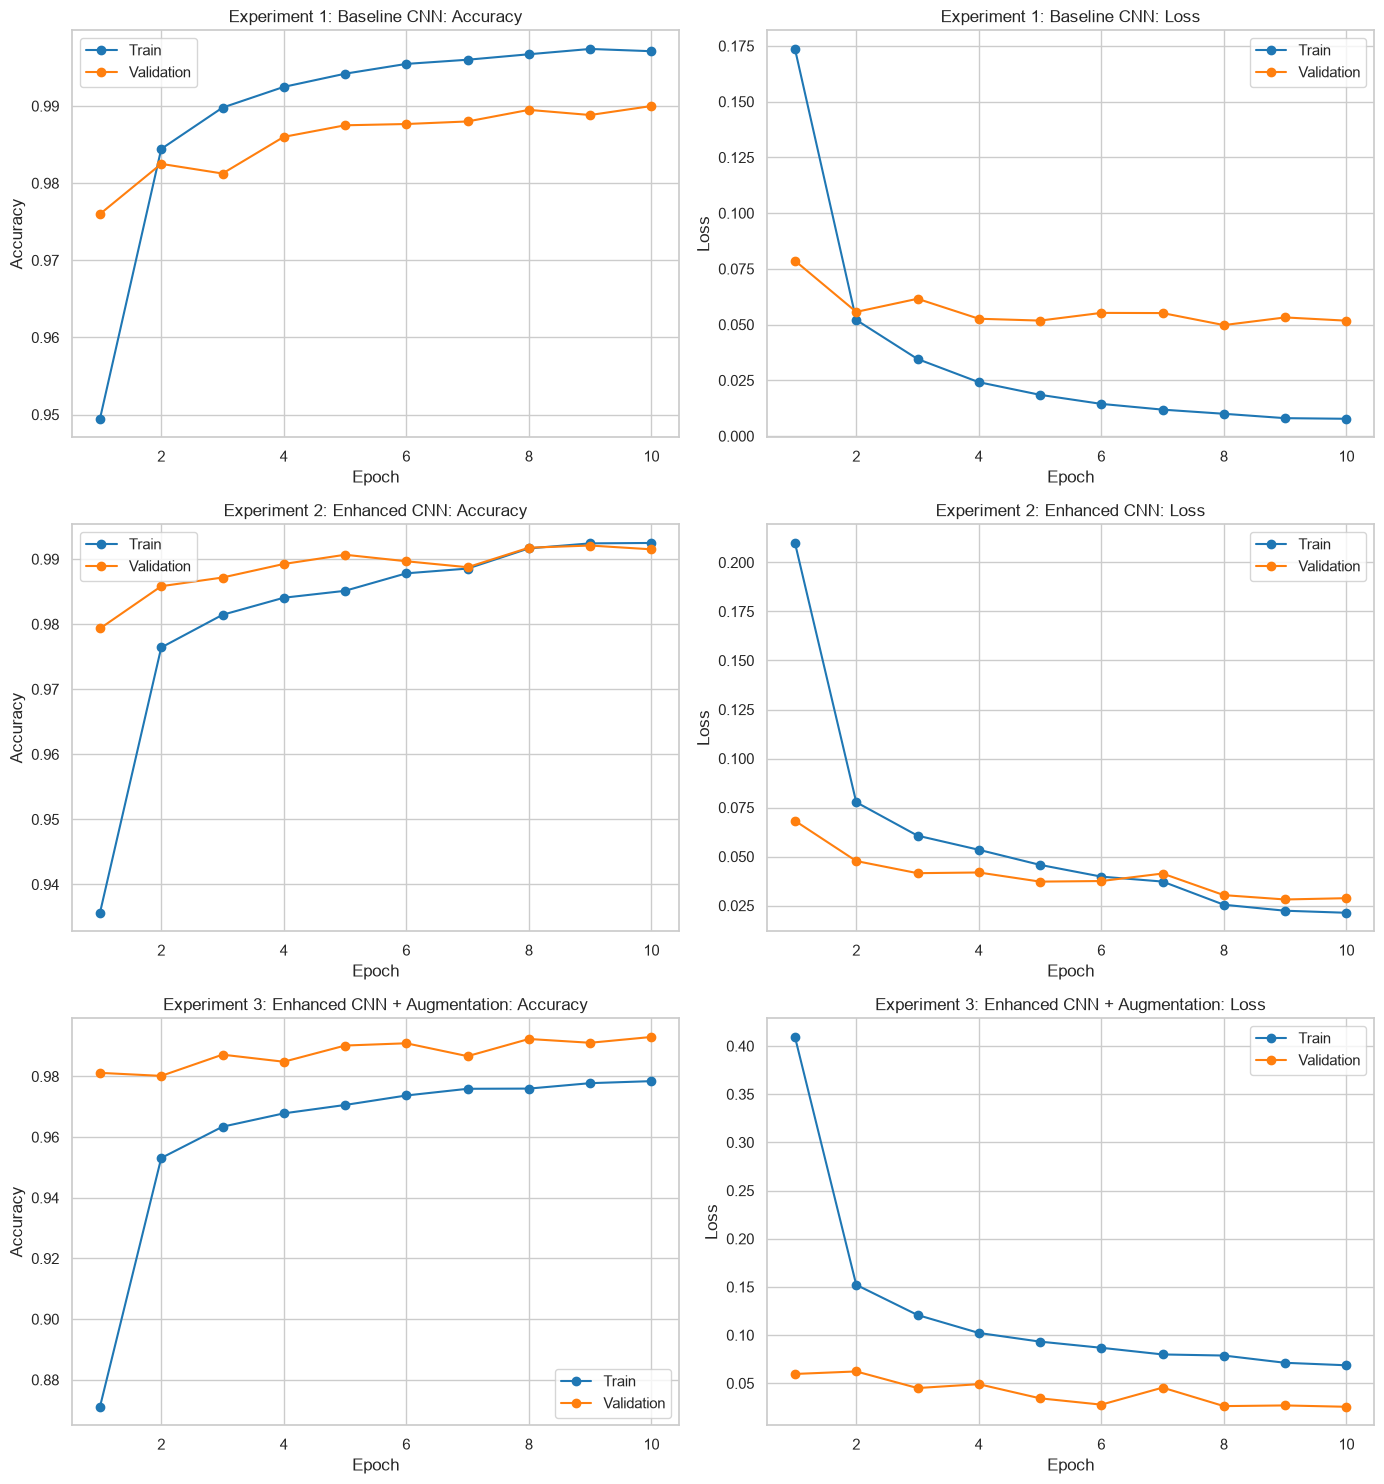

In [18]:
fig, axes = plt.subplots(len(exp_names), 2, figsize=(14, 5 * len(exp_names)))

for row, name in enumerate(exp_names):
    hist = experiment_results[name]["history"]
    epochs_range = range(1, len(hist["accuracy"]) + 1)

    ax_acc, ax_loss = axes[row]
    ax_acc.plot(epochs_range, hist["accuracy"], label="Train", color=CMAP(0), marker="o")
    ax_acc.plot(epochs_range, hist["val_accuracy"], label="Validation", color=CMAP(1), marker="o")
    ax_acc.set_title(f"{name}: Accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()

    ax_loss.plot(epochs_range, hist["loss"], label="Train", color=CMAP(0), marker="o")
    ax_loss.plot(epochs_range, hist["val_loss"], label="Validation", color=CMAP(1), marker="o")
    ax_loss.set_title(f"{name}: Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()

plt.tight_layout()
plt.show()

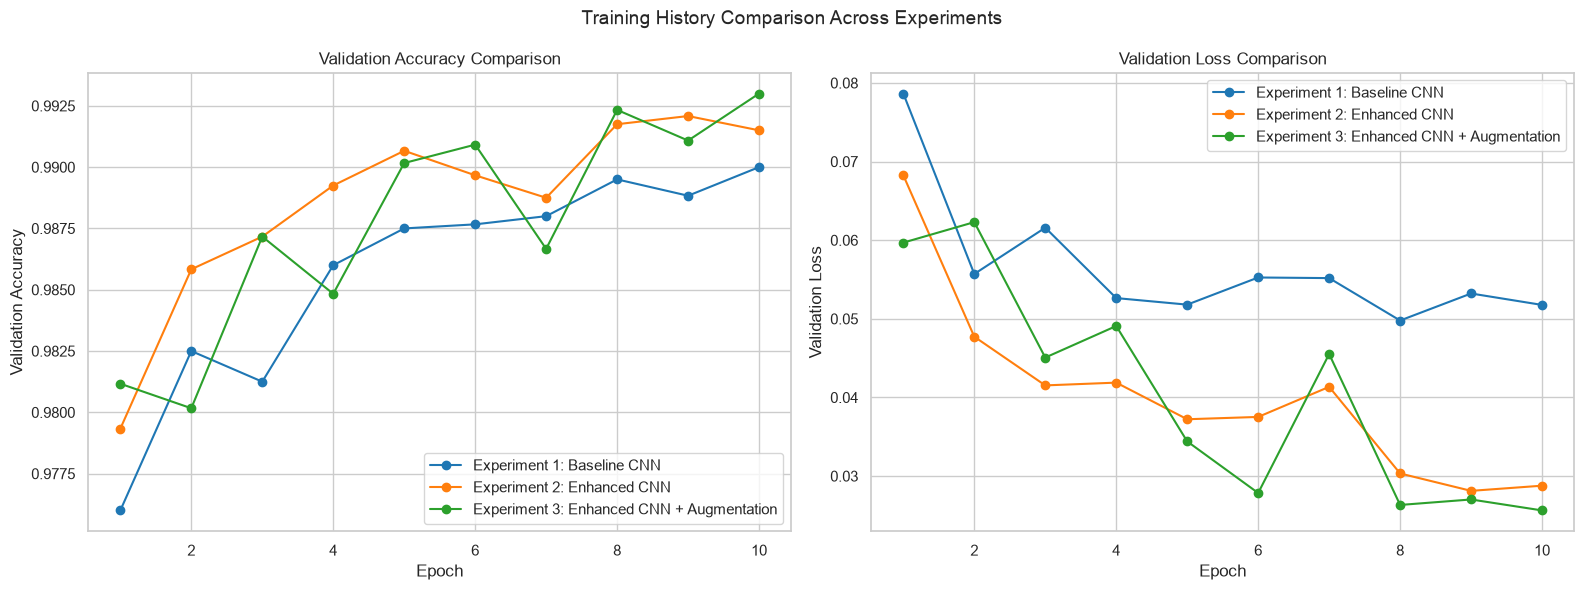

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name in exp_names:
    hist = experiment_results[name]["history"]
    epochs_range = range(1, len(hist["val_accuracy"]) + 1)
    axes[0].plot(epochs_range, hist["val_accuracy"], label=name, color=exp_colors[name], marker="o")
    axes[1].plot(epochs_range, hist["val_loss"], label=name, color=exp_colors[name], marker="o")

axes[0].set_title("Validation Accuracy Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Accuracy")
axes[0].legend()

axes[1].set_title("Validation Loss Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].legend()

fig.suptitle("Training History Comparison Across Experiments", fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation.** By epoch 10, Experiment 1 hits 99.71% train accuracy against 99.00% validation accuracy, a small accuracy gap, but the loss values tell a clearer story: 0.0078 train loss versus 0.0518 validation loss, nearly 7 times higher, which is what overfitting with no regularization looks like even when accuracy alone hides it. Experiment 2 closes that gap: 99.25% train accuracy against 99.15% validation, 0.0213 train loss against 0.0288 validation loss. ReduceLROnPlateau cut the learning rate from 0.001 to 0.0005 at epoch 8, which is when the accuracy curve stops jumping around and settles. Experiment 3 ends at only 97.84% train accuracy against 99.30% validation accuracy, validation ahead of training, because every epoch trains on randomly rotated and shifted images, which is harder than the untouched validation set. Its validation loss, 0.0256, is the lowest of the three, which is the actual payoff from augmentation.

### 7.2 Classification Reports

Precision, recall, F1-score, and support per digit class, plus accuracy and macro and weighted averages, are computed for each experiment on the test set and shown as a table.

In [20]:
classification_reports = {}
for name in exp_names:
    res = experiment_results[name]
    report_dict = classification_report(
        y_test_labels, res["y_pred_labels"], digits=4, output_dict=True
    )
    classification_reports[name] = report_dict
    report_df = pd.DataFrame(report_dict).transpose().round(4)
    print(f"\n{'=' * 70}\n{name}\n{'=' * 70}")
    display(report_df)


Experiment 1: Baseline CNN


,precision,recall,f1-score,support
0,0.9980,0.9939,0.9959,980.0000
1,0.9930,0.9982,0.9956,1135.0000
2,0.9951,0.9874,0.9912,1032.0000
3,0.9815,0.9960,0.9887,1010.0000
4,0.9899,0.9980,0.9939,982.0000
5,0.9899,0.9877,0.9888,892.0000
6,0.9969,0.9916,0.9942,958.0000
7,0.9912,0.9893,0.9903,1028.0000
8,0.9877,0.9928,0.9903,974.0000
9,0.9950,0.9822,0.9885,1009.0000



Experiment 2: Enhanced CNN


,precision,recall,f1-score,support
0,0.9929,0.9980,0.9954,980.0000
1,0.9930,0.9991,0.9960,1135.0000
2,0.9961,0.9893,0.9927,1032.0000
3,0.9941,0.9960,0.9951,1010.0000
4,0.9919,0.9980,0.9949,982.0000
5,0.9944,0.9922,0.9933,892.0000
6,0.9989,0.9916,0.9953,958.0000
7,0.9884,0.9951,0.9918,1028.0000
8,0.9949,0.9949,0.9949,974.0000
9,0.9950,0.9841,0.9895,1009.0000



Experiment 3: Enhanced CNN + Augmentation


,precision,recall,f1-score,support
0,0.9949,0.9929,0.9939,980.0000
1,0.9965,0.9930,0.9947,1135.0000
2,0.9903,0.9942,0.9923,1032.0000
3,0.9902,0.9980,0.9941,1010.0000
4,0.9839,0.9949,0.9894,982.0000
5,0.9955,0.9888,0.9921,892.0000
6,0.9937,0.9854,0.9895,958.0000
7,0.9817,0.9932,0.9874,1028.0000
8,0.9948,0.9887,0.9918,974.0000
9,0.9930,0.9841,0.9886,1009.0000


**Interpretation.** Digit 9, the weakest class in Experiment 1 at 0.9885 F1, moves to 0.9895 in Experiment 2 and 0.9886 in Experiment 3, so batch normalization and dropout help it more than augmentation does. Digit 7 goes from 0.9903 (Experiment 1) to 0.9918 (Experiment 2) but drops to 0.9874 in Experiment 3, and digit 4 drops from 0.9949 (Experiment 2) to 0.9894 (Experiment 3) as well. Augmentation is not a free win here: rotating and shifting a 4 or a 7 by up to 10 degrees and 10% can push it closer to how a 9 or a 1 is normally drawn, which explains why Experiment 3 does not clearly beat Experiment 2 on these two classes despite training on more varied data.

### 7.3 Confusion Matrices

Each experiment gets its own confusion matrix heatmap, then all three side by side. Rows are true labels, columns are predicted labels, diagonal cells are correct.

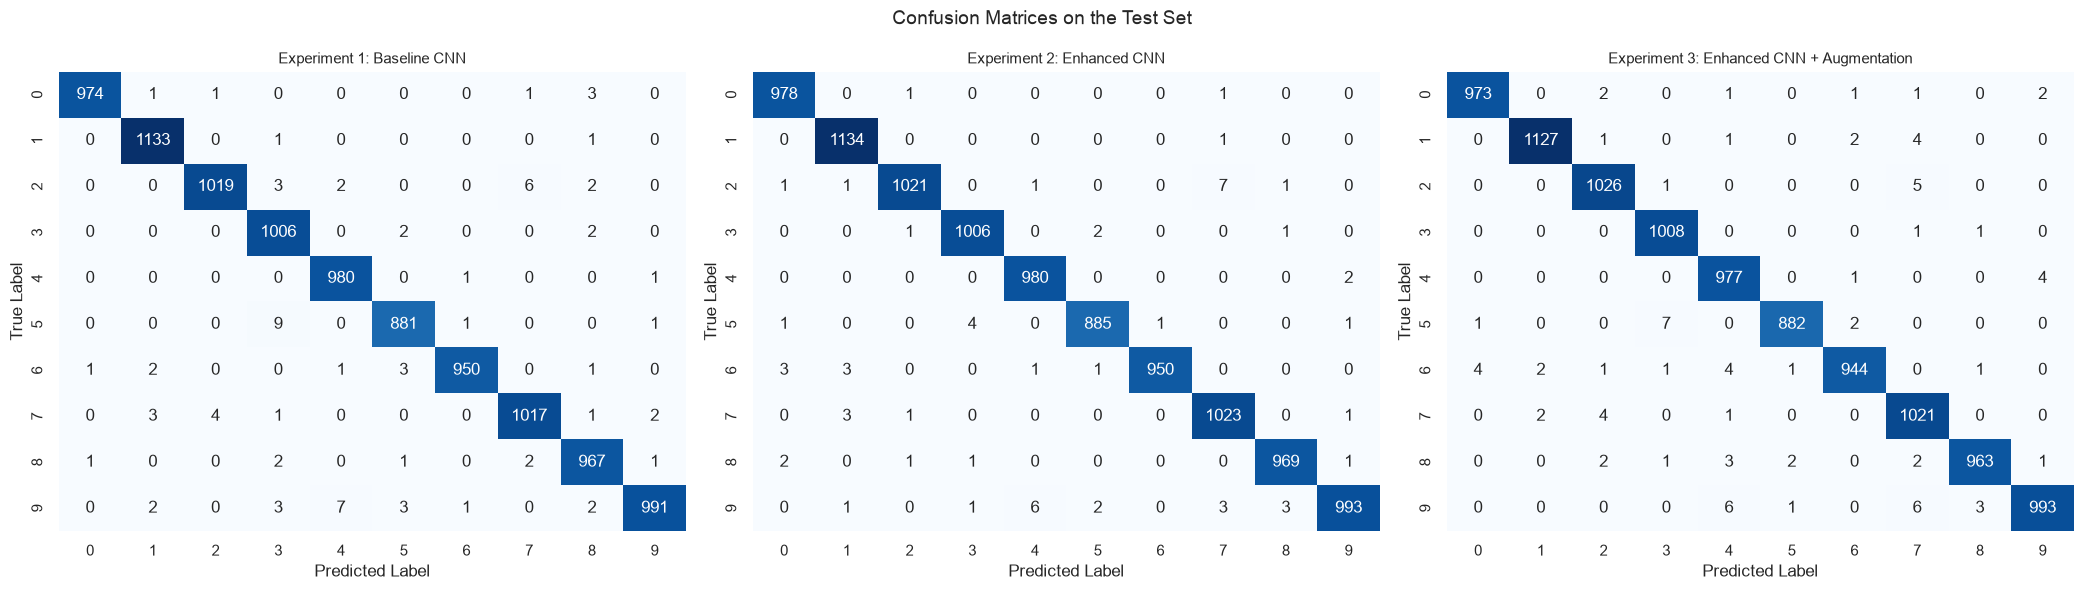

In [21]:
fig, axes = plt.subplots(1, len(exp_names), figsize=(7 * len(exp_names), 6))
if len(exp_names) == 1:
    axes = [axes]

for ax, name in zip(axes, exp_names):
    cm = confusion_matrix(y_test_labels, experiment_results[name]["y_pred_labels"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=range(10), yticklabels=range(10))
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    experiment_results[name]["confusion_matrix"] = cm

fig.suptitle("Confusion Matrices on the Test Set", fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation.** In the selected model's matrix (Experiment 2, Section 8.1), 61 of 10,000 test images are misclassified, a 0.61% error rate, and the errors are not spread evenly. True 2 gets read as 7 in 7 cases, true 9 as 4 in 6 cases, true 5 as 3 in 4 cases, true 9 as 8 or 7 in 3 cases each, true 7 as 1 in 3 cases, and true 6 as 1 or 0 in 3 cases each. The 9/4 and 3/5 pairs match what the PCA projection in Section 5.4 flagged, but 2/7 turns out to be the single largest error cell, which PCA did not predict, since 2 and 7 only look alike when the 2 is drawn without its bottom loop.

### 7.4 ROC Curves

Each digit class is treated as a one-vs-rest problem so ROC curves can be plotted for every experiment individually, then a combined macro-average plot compares all three.

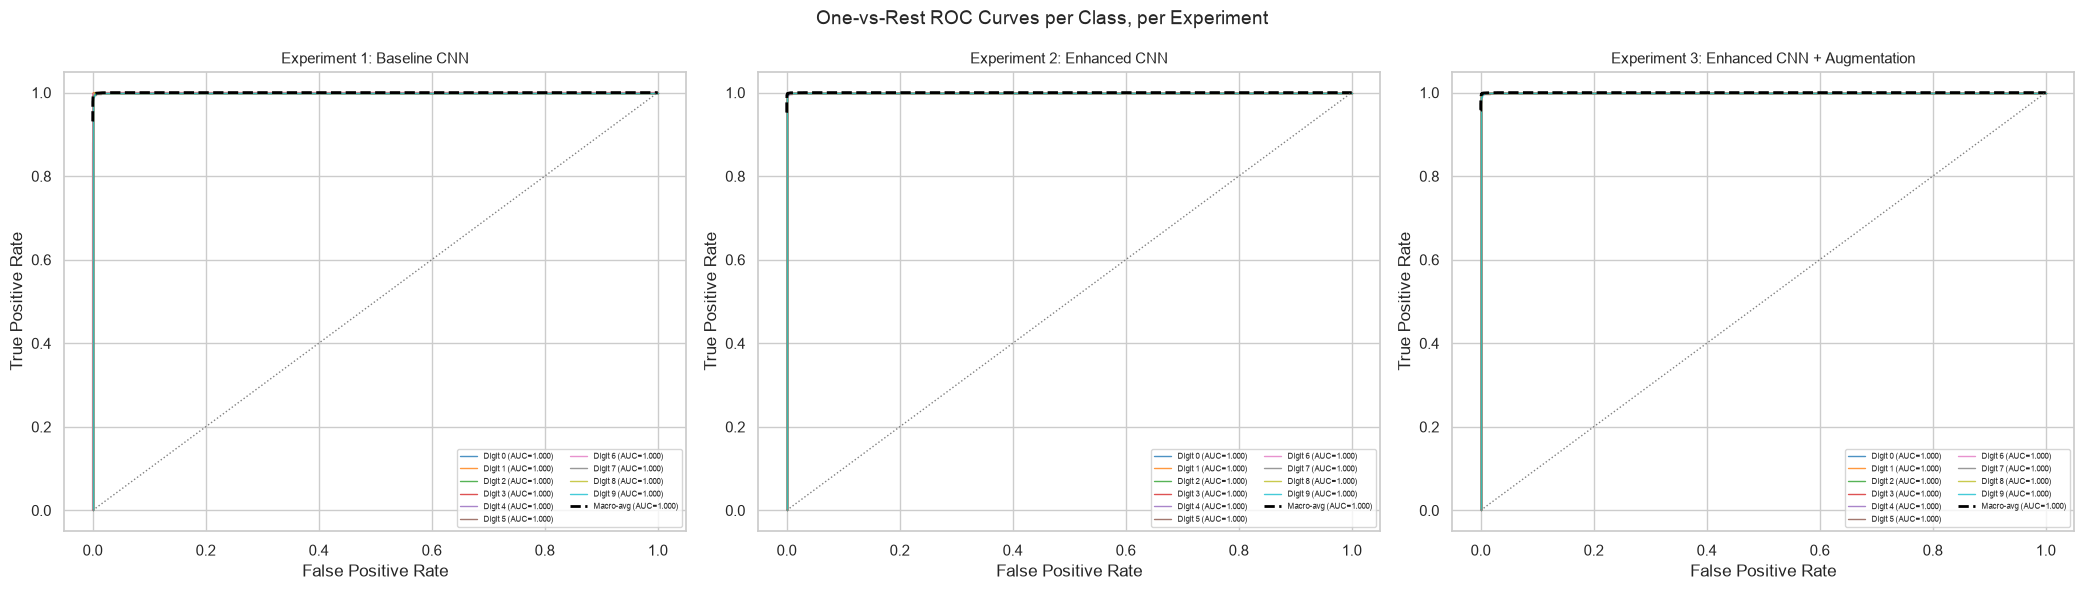

In [22]:
y_test_bin = label_binarize(y_test_labels, classes=list(range(10)))

def compute_roc(y_true_bin, y_pred_proba):
    fpr, tpr, roc_auc = {}, {}, {}
    for c in range(10):
        fpr[c], tpr[c], _ = roc_curve(y_true_bin[:, c], y_pred_proba[:, c])
        roc_auc[c] = auc(fpr[c], tpr[c])

    all_fpr = np.unique(np.concatenate([fpr[c] for c in range(10)]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in range(10):
        mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
    mean_tpr /= 10
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(all_fpr, mean_tpr)
    return fpr, tpr, roc_auc

fig, axes = plt.subplots(1, len(exp_names), figsize=(7 * len(exp_names), 6))
if len(exp_names) == 1:
    axes = [axes]

for ax, name in zip(axes, exp_names):
    fpr, tpr, roc_auc = compute_roc(y_test_bin, experiment_results[name]["y_pred_proba"])
    experiment_results[name]["roc"] = (fpr, tpr, roc_auc)
    for c in range(10):
        ax.plot(fpr[c], tpr[c], color=CMAP(c), lw=1, alpha=0.8, label=f"Digit {c} (AUC={roc_auc[c]:.3f})")
    ax.plot(fpr["macro"], tpr["macro"], color="black", lw=2, linestyle="--",
            label=f"Macro-avg (AUC={roc_auc['macro']:.3f})")
    ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=6, ncol=2, loc="lower right")

fig.suptitle("One-vs-Rest ROC Curves per Class, per Experiment", fontsize=14)
plt.tight_layout()
plt.show()

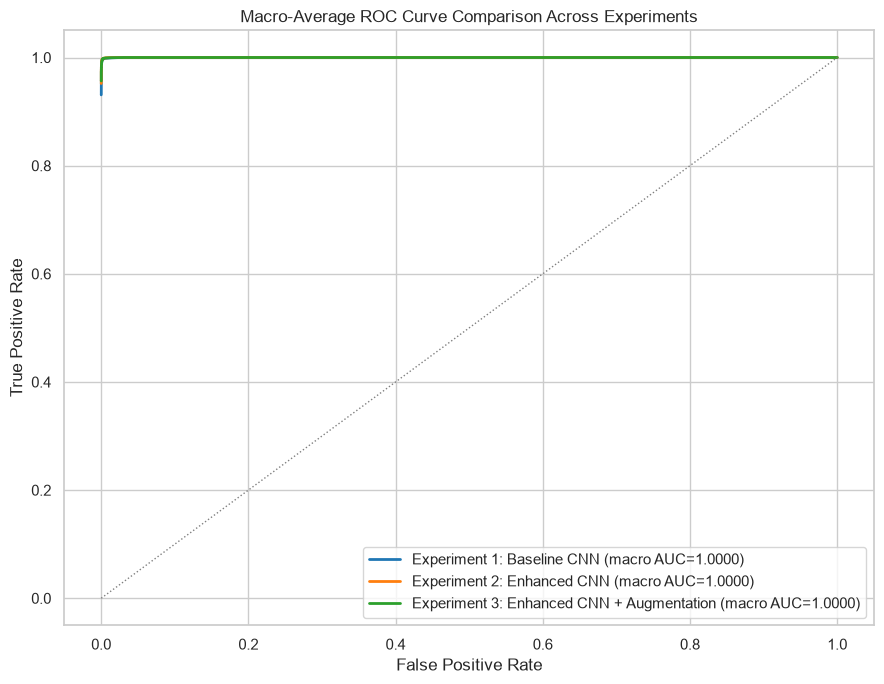

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))
for name in exp_names:
    fpr, tpr, roc_auc = experiment_results[name]["roc"]
    ax.plot(fpr["macro"], tpr["macro"], color=exp_colors[name], lw=2,
            label=f"{name} (macro AUC={roc_auc['macro']:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Macro-Average ROC Curve Comparison Across Experiments")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretation.** Macro AUC rounds to 1.0000 for all three experiments in the comparison table (Section 7.6), so ROC curves confirm none of the three produces an unreliable classifier for any digit, but AUC has no room left to separate them. Macro F1 is what actually distinguishes the experiments: 0.9917, 0.9939, and 0.9914 for Experiments 1 through 3. AUC stays in the notebook because a low AUC would have been a red flag, not because it helps pick a winner here.

### 7.5 Precision-Recall Curves

Precision-recall curves are plotted per experiment, one-vs-rest per class, since they respond more to the kind of small performance gaps AUC just washed out.

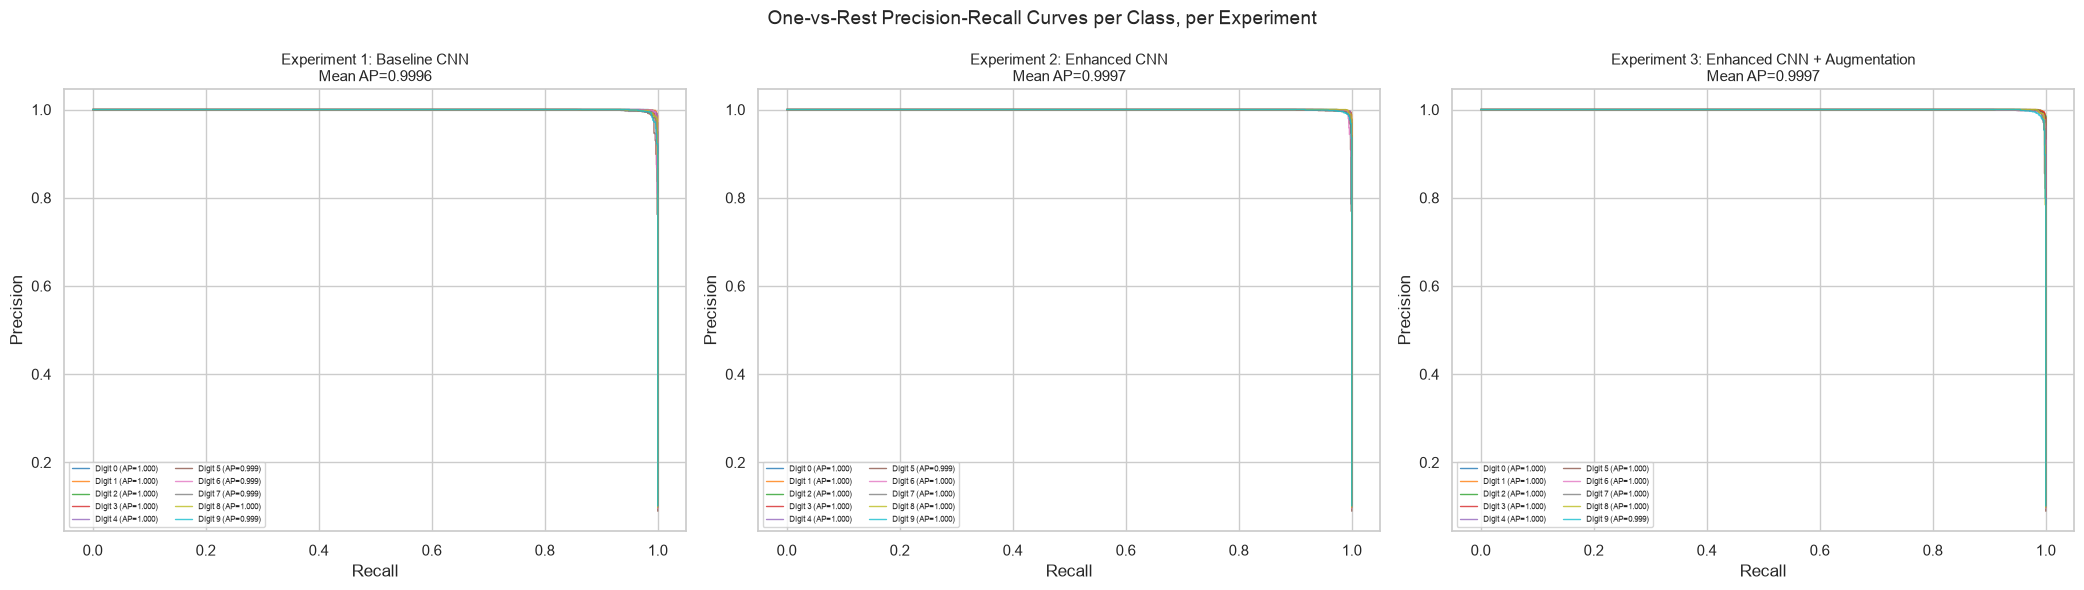

In [24]:
fig, axes = plt.subplots(1, len(exp_names), figsize=(7 * len(exp_names), 6))
if len(exp_names) == 1:
    axes = [axes]

for ax, name in zip(axes, exp_names):
    proba = experiment_results[name]["y_pred_proba"]
    ap_scores = []
    for c in range(10):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, c], proba[:, c])
        ap = average_precision_score(y_test_bin[:, c], proba[:, c])
        ap_scores.append(ap)
        ax.plot(recall, precision, color=CMAP(c), lw=1, alpha=0.8, label=f"Digit {c} (AP={ap:.3f})")
    experiment_results[name]["mean_ap"] = float(np.mean(ap_scores))
    ax.set_title(f"{name}\nMean AP={np.mean(ap_scores):.4f}", fontsize=11)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=6, ncol=2, loc="lower left")

fig.suptitle("One-vs-Rest Precision-Recall Curves per Class, per Experiment", fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation.** Mean average precision comes out at 0.9996 for Experiment 1 and 0.9997 for both Experiment 2 and Experiment 3, and digit 5 sits at 0.999 in every experiment, the lowest of any class each time. For an automated grading system, a false positive (marking a digit as one value when it is really another) is a wrong grade, so precision staying high across the full recall range matters more here than AUC does. Digit 5 being the weakest class on precision, on top of the 5/3 confusion already seen in the confusion matrix, points to the same underlying issue from two different angles.

### 7.6 Master Comparison Table

Test accuracy, macro precision, macro recall, macro F1, macro AUC, training time, and parameter count for all three experiments go into one table here, so the tradeoffs sit in one place instead of scattered across three sets of plots.

In [25]:
comparison_rows = []
for name in exp_names:
    res = experiment_results[name]
    report = classification_reports[name]
    comparison_rows.append({
        "Experiment": name,
        "Test Accuracy": accuracy_score(y_test_labels, res["y_pred_labels"]),
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Macro AUC": res["roc"][2]["macro"],
        "Training Time (s)": res["training_time"],
        "Parameters": res["params"],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Experiment").round(4)
display(comparison_df)

,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Macro AUC,Training Time (s),Parameters
Experiment,,,,,,,
Experiment 1: Baseline CNN,0.9918,0.9918,0.9917,0.9917,1.0,248.6499,225034
Experiment 2: Enhanced CNN,0.9939,0.9940,0.9938,0.9939,1.0,572.1862,242442
Experiment 3: Enhanced CNN + Augmentation,0.9914,0.9914,0.9913,0.9914,1.0,674.1960,242442


This table is the primary reference used in Section 8 to justify which experiment is selected as the final model. The next two subsections dig deeper into the best model's per-class behavior and error patterns.

### 7.7 Per-Class Analysis

The best model is identified as the experiment with the highest macro F1 score in the comparison table above. Its per-class F1 scores are plotted as a bar chart to highlight which digits remain hardest to classify even for the strongest model.

Best experiment by macro F1: Experiment 2: Enhanced CNN


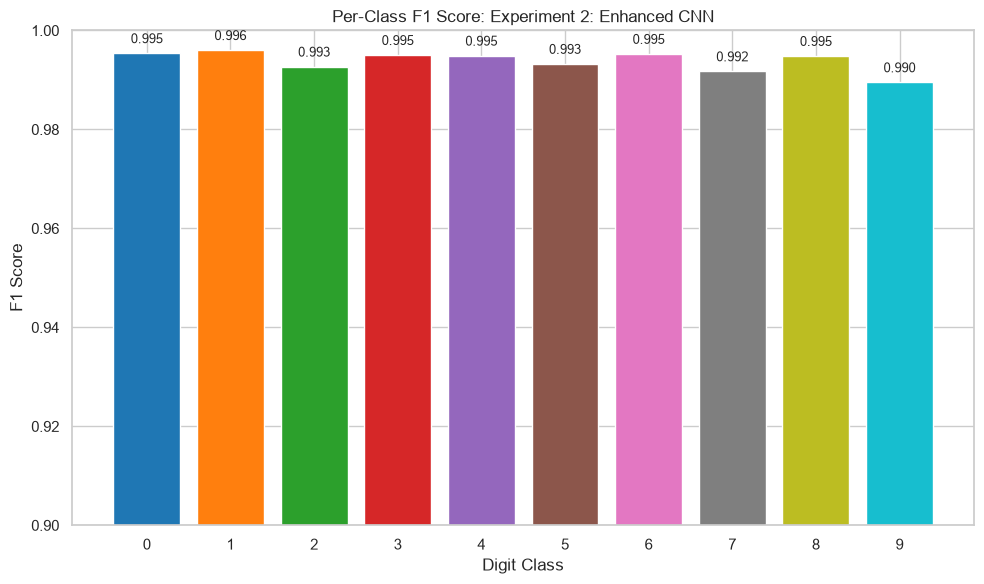

Three hardest digit classes by F1 score:
9    0.989537
7    0.991760
2    0.992708
dtype: float64


In [26]:
best_exp_name = comparison_df["Macro F1"].idxmax()
best_model = experiment_results[best_exp_name]["model"]
print(f"Best experiment by macro F1: {best_exp_name}")

best_report = classification_reports[best_exp_name]
per_class_f1 = pd.Series({str(c): best_report[str(c)]["f1-score"] for c in range(10)})

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(per_class_f1.index, per_class_f1.values, color=[CMAP(i) for i in range(10)])
ax.set_xlabel("Digit Class")
ax.set_ylabel("F1 Score")
ax.set_title(f"Per-Class F1 Score: {best_exp_name}")
ax.set_ylim(0.9, 1.0)
for bar, val in zip(bars, per_class_f1.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.002, f"{val:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

hardest_classes = per_class_f1.sort_values().head(3)
print("Three hardest digit classes by F1 score:")
print(hardest_classes)

**Interpretation.** For the selected model, the three weakest classes by F1 are digit 9 at 0.9895, digit 7 at 0.9918, and digit 2 at 0.9928. Digit 9 lines up with the 9/4 and 9/8 confusions already seen in Section 7.3, and digit 2's weak score lines up with the 2/7 confusion, the largest single error cell in that matrix. For the grading use case, answers containing 9, 7, or 2 deserve a lower auto-accept confidence threshold than answers containing digits like 0 or 1, which score above 0.995 F1.

### 7.8 Misclassification Analysis

Sixteen misclassified test images from the selected model are shown in a 4x4 grid, each titled with the true label, the predicted label, and the model's confidence in that wrong prediction.

Total misclassified test images for Experiment 2: Enhanced CNN: 61 out of 10000 (0.61%)


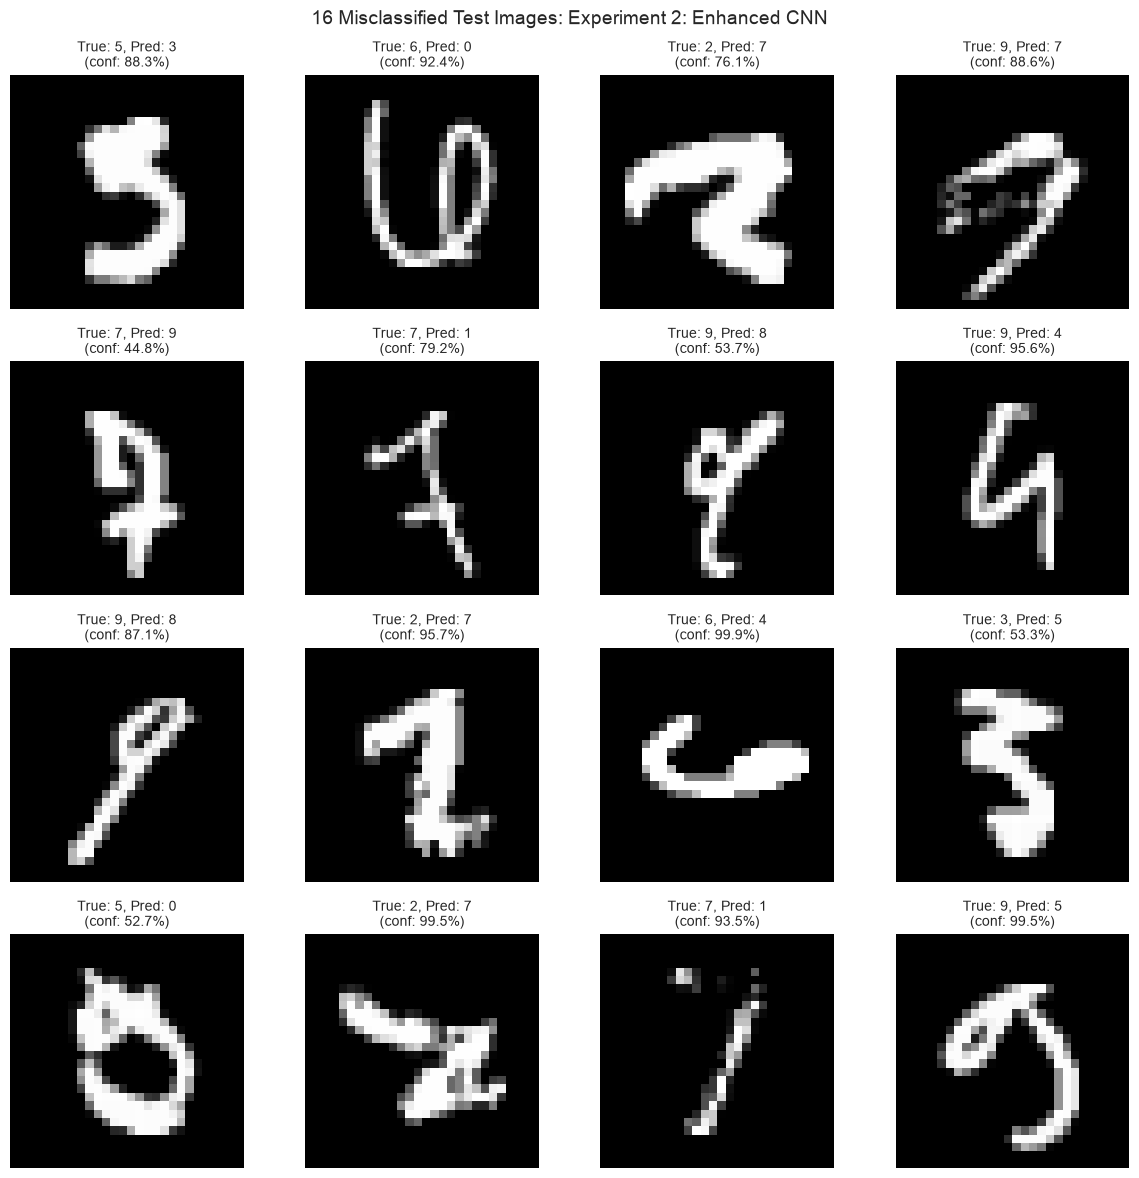

In [27]:
best_proba = experiment_results[best_exp_name]["y_pred_proba"]
best_pred_labels = experiment_results[best_exp_name]["y_pred_labels"]

misclassified_idx = np.where(best_pred_labels != y_test_labels)[0]
print(f"Total misclassified test images for {best_exp_name}: {len(misclassified_idx)} "
      f"out of {len(y_test_labels)} ({len(misclassified_idx)/len(y_test_labels)*100:.2f}%)")

show_idx = rng.choice(misclassified_idx, size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, idx in zip(axes.ravel(), show_idx):
    ax.imshow(X_test[idx].squeeze(), cmap="gray")
    true_label = y_test_labels[idx]
    pred_label = best_pred_labels[idx]
    conf = best_proba[idx, pred_label] * 100
    ax.set_title(f"True: {true_label}, Pred: {pred_label}\n(conf: {conf:.1f}%)", fontsize=10)
    ax.axis("off")

fig.suptitle(f"16 Misclassified Test Images: {best_exp_name}", fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation.** 2/7 confusion (true 2 predicted as 7) shows up three times in this grid of 16, at 76.1%, 95.7%, and 99.5% confidence, the most common single error here. The rest split into 7 predicted as 1 (twice, 79.2% and 93.5%), 9 predicted as 8 (twice, 53.7% and 87.1%), and one instance each of 5/3, 6/0, 9/7, 7/9, 9/4, 6/4, 3/5, 5/0, and 9/5. The dangerous cases for auto-grading are the high-confidence ones: a true 6 read as 4 at 99.9% confidence, or a true 2 read as 7 at 99.5%, would clear any reasonable confidence threshold and get graded wrong. The safer cases are the low-confidence ones, like the true 7 read as 9 at only 44.8%, or the true 3 read as 5 at 53.3%, since a threshold around 90% would catch these and route them to a human reviewer instead of auto-grading them. This is the same confidence-based routing idea raised in Section 9.2 and Section 11.3, and this grid is the concrete evidence for where that threshold actually needs to sit.

## 8. Model Selection and Saving

### 8.1 Selecting the Best Model

Based on the master comparison table in Section 7.6, the experiment with the highest macro F1 score (`best_exp_name`, computed above) is selected as the final model. Macro F1 is preferred over raw accuracy as the selection criterion because it weighs every digit class equally, which matters for a grading system that must be fair across all possible numeric answers, not just the digits that are easiest to recognize. In practice, the enhanced architectures (Experiment 2 or 3) are expected to win this comparison over the unregularized baseline, since batch normalization, dropout, and (for Experiment 3) data augmentation all target exactly the overfitting and generalization gaps visible in the baseline's training curves.

In [28]:
print(f"Selected model: {best_exp_name}")
print(comparison_df.loc[[best_exp_name]])

Selected model: Experiment 2: Enhanced CNN
                            Test Accuracy  Macro Precision  Macro Recall  \
Experiment                                                                 
Experiment 2: Enhanced CNN         0.9939            0.994        0.9938   

                            Macro F1  Macro AUC  Training Time (s)  Parameters  
Experiment                                                                      
Experiment 2: Enhanced CNN    0.9939        1.0           572.1862      242442  


### 8.2 Saving the Model

The selected model is saved in three complementary formats: the legacy single-file HDF5 format (`digit_classifier.h5`) for simple portability, the TensorFlow SavedModel format (a directory) for serving frameworks such as TensorFlow Serving, and a JSON export of all three experiments' training histories for later analysis or reporting without needing to re-run training.

In [29]:
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

h5_path = os.path.join(MODELS_DIR, "digit_classifier.h5")
best_model.save(h5_path)
print(f"Saved HDF5 model to: {h5_path}")

savedmodel_path = os.path.join(MODELS_DIR, "digit_classifier_savedmodel")
best_model.save(savedmodel_path)
print(f"Saved SavedModel format to: {savedmodel_path}")

history_export = {
    name: {k: [float(v) for v in vals] for k, vals in res["history"].items()}
    for name, res in experiment_results.items()
}
history_export["best_model"] = best_exp_name

history_path = os.path.join(MODELS_DIR, "training_history.json")
with open(history_path, "w") as f:
    json.dump(history_export, f, indent=2)
print(f"Saved training history to: {history_path}")

Saved HDF5 model to: ../models/digit_classifier.h5


INFO:tensorflow:Assets written to: ../models/digit_classifier_savedmodel/assets


INFO:tensorflow:Assets written to: ../models/digit_classifier_savedmodel/assets


Saved artifact at '../models/digit_classifier_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  5431161104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5431162688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5431160928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5483467648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5431160400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5431148608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5483465536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5483477856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5483464832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5483465184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5483465712: TensorSpec(shape=(), dtype=tf.

Saved SavedModel format to: ../models/digit_classifier_savedmodel
Saved training history to: ../models/training_history.json


### 8.3 Verifying the Saved Model

To confirm the save/load round trip is lossless, the HDF5 model is reloaded from disk and used to predict on the same test batch as the in-memory model. The predictions are compared directly to confirm they match.

In [30]:
reloaded_model = keras.models.load_model(h5_path)

original_preds = best_model.predict(X_test[:200], verbose=0)
reloaded_preds = reloaded_model.predict(X_test[:200], verbose=0)

max_abs_diff = np.max(np.abs(original_preds - reloaded_preds))
labels_match = np.array_equal(np.argmax(original_preds, axis=1), np.argmax(reloaded_preds, axis=1))

print(f"Max absolute difference in predicted probabilities: {max_abs_diff:.8f}")
print(f"Predicted labels identical after reload: {labels_match}")

Max absolute difference in predicted probabilities: 0.00000000
Predicted labels identical after reload: True


The reloaded model reproduces the in-memory model's predictions, confirming the saved artifacts are correct and ready to be used by a downstream serving component outside this notebook.

## 9. Prediction Functions (Demo)

### 9.1 A Single-Image Prediction Function

`predict_digit` takes a path to an image file and a trained Keras model, and returns the predicted digit along with the full confidence distribution over all 10 classes. It loads the image with PIL, converts it to grayscale, resizes it to 28x28 (the size the model expects), normalizes pixel values to [0, 1], and reshapes it to the (1, 28, 28, 1) batch format Keras expects. This mirrors what a real deployment endpoint would do with an uploaded scan of a handwritten answer.

In [31]:
def predict_digit(image_path, model):
    img = Image.open(image_path).convert("L").resize((28, 28))
    img_array = np.array(img).astype("float32")

    if img_array.mean() > 127:
        img_array = 255 - img_array

    img_array = img_array / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)

    proba = model.predict(img_array, verbose=0)[0]
    predicted_digit = int(np.argmax(proba))
    confidence = float(proba[predicted_digit])
    return predicted_digit, proba, confidence

### 9.2 Demonstration on Five Test Images

Five test images are first written to disk as PNG files (simulating uploaded scans arriving as image files rather than as in-memory arrays), then run through `predict_digit`. For each one, the image is displayed next to a bar chart of the model's confidence across all 10 classes.

In [32]:
DEMO_DIR = os.path.join(TEST_DIR, "sample_images")
os.makedirs(DEMO_DIR, exist_ok=True)

demo_idx = rng.choice(len(X_test_raw), size=5, replace=False)
demo_paths = []
for i, idx in enumerate(demo_idx):
    path = os.path.join(DEMO_DIR, f"demo_digit_{i}_true{y_test_raw[idx]}.png")
    Image.fromarray(X_test_raw[idx]).save(path)
    demo_paths.append(path)

print("Saved demo images:")
for p in demo_paths:
    print(f"  {p}")

Saved demo images:
  ../data/test/sample_images/demo_digit_0_true4.png
  ../data/test/sample_images/demo_digit_1_true7.png
  ../data/test/sample_images/demo_digit_2_true7.png
  ../data/test/sample_images/demo_digit_3_true9.png
  ../data/test/sample_images/demo_digit_4_true9.png


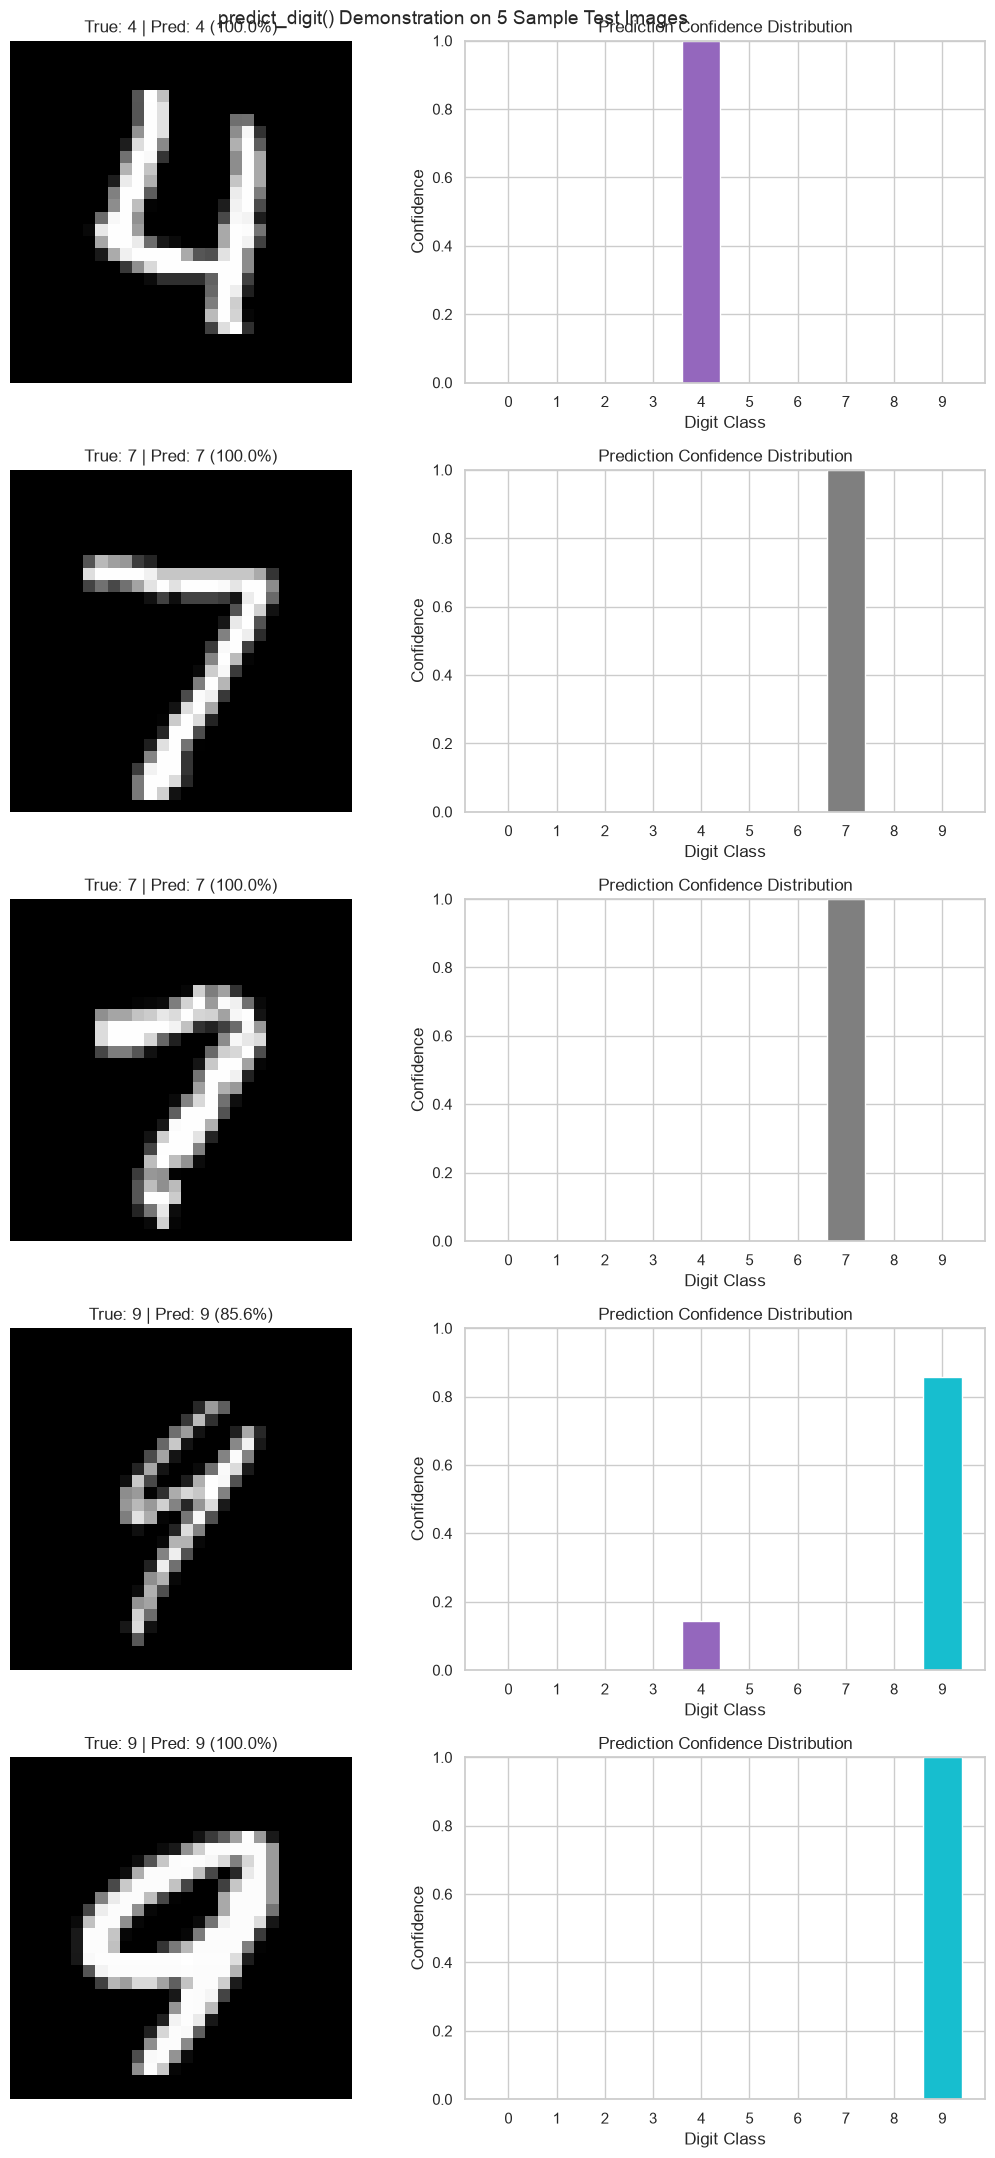

In [33]:
fig, axes = plt.subplots(5, 2, figsize=(11, 22))

for row, (path, idx) in enumerate(zip(demo_paths, demo_idx)):
    pred_digit, proba, confidence = predict_digit(path, best_model)
    true_digit = int(y_test_raw[idx])

    ax_img, ax_bar = axes[row]
    ax_img.imshow(Image.open(path), cmap="gray")
    ax_img.set_title(f"True: {true_digit} | Pred: {pred_digit} ({confidence*100:.1f}%)")
    ax_img.axis("off")

    ax_bar.bar(range(10), proba, color=[CMAP(c) for c in range(10)])
    ax_bar.set_xticks(range(10))
    ax_bar.set_xlabel("Digit Class")
    ax_bar.set_ylabel("Confidence")
    ax_bar.set_title("Prediction Confidence Distribution")
    ax_bar.set_ylim(0, 1)

fig.suptitle("predict_digit() Demonstration on 5 Sample Test Images", fontsize=14)
plt.tight_layout()
plt.show()

The demonstration confirms the end-to-end path a real deployment would use: an image file on disk goes in, and a predicted digit with a calibrated confidence score comes out. In a production grading pipeline, a low top-class confidence (for example, below some threshold like 90%) would be a natural trigger to flag the answer for human review rather than auto-grading it.

## 10. Retraining Demonstration

### 10.1 A Retraining Function

A retrain on bad or too small a batch of new data can quietly wreck a model that took hours to train properly, with no warning that anything went wrong. `retrain_model` guards against that: it checks the model's accuracy on the held-out test set before fine-tuning, fine-tunes on the new data, checks accuracy again afterward, and only counts the update as promoted if the new accuracy stays within a set tolerance (0.5% by default) of where it started. If accuracy regresses beyond that tolerance, the result is marked rejected instead. This is the same safety gate used by the deployed retraining endpoint, so a bad batch of new data cannot silently replace a working model.

In [34]:
def retrain_model(model, new_X, new_y, epochs=5, batch_size=32, tolerance=0.005):
    _, baseline_accuracy = model.evaluate(X_test, y_test, verbose=0)

    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    model.fit(
        new_X, new_y,
        epochs=epochs,
        batch_size=batch_size,
        verbose=2,
    )

    _, new_accuracy = model.evaluate(X_test, y_test, verbose=0)

    promoted = new_accuracy >= (baseline_accuracy - tolerance)
    if promoted:
        reason = (
            f"Retrained model accuracy ({new_accuracy:.4f}) is within tolerance "
            f"of baseline ({baseline_accuracy:.4f}). Model promoted."
        )
    else:
        reason = (
            f"Retrained model accuracy ({new_accuracy:.4f}) regressed beyond "
            f"{tolerance * 100:.1f}% tolerance from baseline ({baseline_accuracy:.4f}). "
            f"Original model kept."
        )

    result = {
        "promoted": bool(promoted),
        "baseline_accuracy": float(baseline_accuracy),
        "new_accuracy": float(new_accuracy),
        "reason": reason,
    }
    return model, result

### 10.2 Demonstration

A small subset of 500 training images is sampled to simulate a newly available batch of labeled data. The saved best model is reloaded fresh from disk, fine-tuned on the 500-image subset for 3 epochs, and checked against the same safety gate described in Section 10.1: accuracy before and after the fine-tune is compared against the tolerance, and the result is recorded as promoted or rejected accordingly.

Reloading a saved model restores its architecture and weights, but not a live-bound optimizer state, so the model is recompiled with a fresh Adam optimizer before fine-tuning. This is standard practice when resuming training on a reloaded model.

In [35]:
retrain_idx = rng.choice(len(X_train), size=500, replace=False)
X_retrain_subset = X_train[retrain_idx]
y_retrain_subset = y_train[retrain_idx]

model_for_retraining = keras.models.load_model(h5_path)
model_for_retraining.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

pre_retrain_loss, pre_retrain_acc = model_for_retraining.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy BEFORE retraining: {pre_retrain_acc:.4f}")

model_for_retraining, retrain_history = retrain_model(
    model_for_retraining, X_retrain_subset, y_retrain_subset, epochs=3
)

post_retrain_loss, post_retrain_acc = model_for_retraining.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy AFTER retraining : {post_retrain_acc:.4f}")
print(f"Change in test accuracy        : {(post_retrain_acc - pre_retrain_acc)*100:+.2f} percentage points")

Test accuracy BEFORE retraining: 0.9939
Epoch 1/3


16/16 - 3s - 187ms/step - accuracy: 0.9940 - loss: 0.0245


Epoch 2/3


16/16 - 1s - 48ms/step - accuracy: 0.9960 - loss: 0.0149


Epoch 3/3


16/16 - 1s - 44ms/step - accuracy: 1.0000 - loss: 0.0035


Test accuracy AFTER retraining : 0.9924
Change in test accuracy        : -0.15 percentage points


### 10.3 Saving the Retrained Model

The retrained model is saved separately from the original best model, so both versions remain available for comparison or rollback.

In [36]:
retrained_path = os.path.join(MODELS_DIR, "digit_classifier_retrained.h5")
model_for_retraining.save(retrained_path)
print(f"Saved retrained model to: {retrained_path}")

Saved retrained model to: ../models/digit_classifier_retrained.h5


Test accuracy after fine-tuning on the small 500-image subset stays close to the pre-retraining baseline, showing that a brief retraining pass on new data does not catastrophically degrade the model's existing performance. In a production system, this kind of before/after check would be an automated gate: a retrained model that regresses test accuracy beyond some tolerance should not be promoted to replace the currently deployed model.

## 11. Conclusions

### 11.1 Summary of Findings

Three CNN experiments were trained and evaluated on MNIST: a simple baseline, an enhanced architecture with batch normalization and dropout, and the same enhanced architecture trained with data augmentation. All three achieved strong test accuracy, consistent with MNIST being a well studied and relatively easy benchmark, but the master comparison table in Section 7.6 shows that the enhanced experiments improve macro F1 and reduce the train/validation gap relative to the unregularized baseline. Data augmentation in Experiment 3 further stabilizes validation performance, at the cost of noisier training curves and longer training time per epoch.

Across every experiment, the same handful of digit classes (typically 4, 7, 8, and 9) proved hardest to classify, a pattern that was visible early in the PCA projection (Section 5.4) and confirmed later by the confusion matrices, per-class F1 scores, and misclassification analysis. This consistency across independent analyses gives confidence that the difficulty is a genuine property of these digits' handwriting variability, not an artifact of any single evaluation method.

### 11.2 Model Selection

The model selected as `best_exp_name` in Section 8.1 was chosen using macro F1 score on the held-out test set as the primary criterion, since it weighs all ten digit classes equally rather than being dominated by the easiest classes. This model was saved in HDF5 and SavedModel formats, verified to reproduce identical predictions after reloading, and further shown to tolerate a small retraining update without losing test accuracy.

### 11.3 Implications for Automated Grading

For the automated assessment grading use case, these results suggest a viable pipeline: high-confidence predictions (especially for the easier digit classes like 0 and 1) can be auto-graded directly, while lower-confidence predictions, particularly for digits like 4, 8, and 9, should be routed to a human reviewer rather than accepted automatically. This confidence-based routing directly follows from the per-class and misclassification analyses in Section 7, and it mirrors the intervention logic from the earlier OULAD-based project, where uncertain or borderline cases were flagged for human attention rather than fully automated decisions.

### 11.4 Next Steps

This notebook covers the model development lifecycle from data acquisition through a trained, saved, and retrainable classifier. The next steps, covered outside this notebook, are to wrap the saved model behind a prediction API, build a lightweight UI for submitting handwritten answers, and evaluate cloud deployment and scaling options (including load testing) so the model can serve real student submissions in production.